In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [108]:
import numpy as np
import seaborn as sns
import missingno as msno

# Phase 1: Data Exploration & Initial Assessment


# Project Context

This project analyzes the **Olist Brazilian E-commerce Dataset**, a comprehensive collection of information about:

- Online orders  
- Customers  
- Sellers  
- Products  
- Payments  
- Customer reviews  
- Delivery performance  


#  Problem Statement - Olist E-commerce Dataset

The Olist dataset contains detailed transactional data from a Brazilian e-commerce marketplace, including information about **orders**, **customers**, **sellers**, **products**, **payments**, **delivery performance**, **reviews**, and **geolocation**.

Despite having a large volume of sales, Olist faces several operational and customer experience challenges such as:
- Delayed deliveries  
- High logistics cost  
- Low customer review scores  
- High cancellation rates  
- Regional delivery inefficiencies  

The purpose of this analysis is to understand **customer behavior**, **seller performance**, **logistics patterns**, and **product category trends** using the merged dataset.  
The insights generated will help identify bottlenecks, improve operations, and enhance customer satisfaction.



##  Key Business Problems to Solve


## **1. Delivery Performance Issues**
- How long does it take to deliver an order?  
- What percentage of orders are delivered late?  
- Which states or cities have the longest delivery delays?  
- How do delivery delays affect customer review scores?



## **2. Customer Satisfaction & Review Analysis**
- What factors influence customer review scores?  
- Which product categories have the best and worst ratings?  
- What patterns exist in 1-star vs 5-star reviews?



## **3. Sales & Revenue Insights**
- Which product categories generate the most revenue?  
- Which sellers perform best in terms of sales volume and reliability?  
- What is the distribution of order values and freight charges?



## **4. Payment Behavior Analysis**
- How do customers pay? (Credit card, boleto, vouchers, installments)  
- What is the impact of high installments on total revenue?  
- Are payment delays linked to delivery delays?



## **5. Geographical Insights**
- Where do most customers come from?  
- How does seller-to-customer distance affect delivery time?  
- Which regions have the highest order density?



## **6. Operational Efficiency**
- Are there outliers in product weight, dimensions, price, or freight value?  
- Which sellers consistently ship late or fail to meet deadlines?  
- How can Olist optimize logistics based on observed patterns?



This problem statement sets the foundation for a comprehensive analysis of the Olist e-commerce ecosystem, enabling data-driven decision-making and operational improvements.



# Step 1: Data Understanding — Olist E-commerce Dataset

This dataset is created by **merging 9 different CSV files** from Olist:
- Customers  
- Orders  
- Order Items  
- Products  
- Sellers  
- Payments  
- Reviews  
- Category Translation  
- Geolocation  

Below are the tasks followed to load, merge, and understand the data.


## 1. Load All Raw CSV Files

```python
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
category = pd.read_csv("product_category_name_translation.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")


In [109]:
customers = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_customers_dataset.csv\olist_customers_dataset.csv")
order_items = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_order_items_dataset.csv\olist_order_items_dataset.csv")
payments = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_order_payments_dataset.csv\olist_order_payments_dataset.csv")
reviews = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_order_reviews_dataset.csv\olist_order_reviews_dataset.csv")
orders   = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_orders_dataset.csv\olist_orders_dataset.csv")
product = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_products_dataset.csv\olist_products_dataset.csv")
sellers = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_sellers_dataset.csv")
category = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\product_category_name_translation.csv")

## Merge the Datasets into One Master DataFrame

In [110]:
Olist = orders.merge(customers, on="customer_id", how="left")

Olist = Olist.merge(order_items, on="order_id", how="left")

Olist = Olist.merge(product, on="product_id", how="left")

Olist = Olist.merge(sellers, on="seller_id", how="left")

Olist = Olist.merge(payments, on="order_id", how="left", suffixes=("", "_payment"))

Olist = Olist.merge(reviews, on="order_id", how="left", suffixes=("", "_review"))

In [111]:
Olist = Olist.merge(category,on = 'product_category_name',how = 'left')

In [112]:
geolocation = pd.read_csv(rf"D:\Desktop\PANDAS\E - COMMERCE DATA\olist_geolocation_dataset.csv\olist_geolocation_dataset.csv")

## Merge geolocation by customer city/state:

In [113]:
geo_loc = geolocation.groupby(['geolocation_state',"geolocation_city"])[['geolocation_lat',"geolocation_lng"]].mean().reset_index()
geo_loc

,geolocation_state,geolocation_city,geolocation_lat,geolocation_lng
0,AC,acrelandia,-10.053606,-67.032126
1,AC,acrelândia,-10.076679,-67.053564
2,AC,assis brasil,-10.935106,-69.557831
3,AC,brasileia,-11.009890,-68.747184
4,AC,brasiléia,-10.999623,-68.752361
...,...,...,...,...
8458,TO,tupirama,-8.971529,-48.188261
8459,TO,wanderlandia,-6.850253,-47.965372
8460,TO,wanderlândia,-6.851796,-47.965097
8461,TO,xambioa,-6.419720,-48.532431


In [114]:
Olist = Olist.merge(geo_loc,left_on=['customer_state', 'customer_city'],right_on=['geolocation_state', 'geolocation_city'],how='left')

In [115]:
Olist

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,geolocation_state,geolocation_city,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery,BA,barreiras,-12.148291,-44.967260
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto,GO,vianopolis,-16.745552,-48.514168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119146,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,baby,SP,praia grande,-24.021424,-46.461824
119147,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,home_appliances_2,BA,nova vicosa,-17.897617,-39.391238
119148,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,computers_accessories,RJ,japuiba,-22.562819,-42.695133
119149,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,computers_accessories,RJ,japuiba,-22.562819,-42.695133


## 2. View Sample Data

In [116]:
Olist.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,geolocation_state,geolocation_city,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery,BA,barreiras,-12.148291,-44.967260
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto,GO,vianopolis,-16.745552,-48.514168


## Check Dataset Structure

In [117]:
Olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119151 entries, 0 to 119150
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119151 non-null  object 
 1   customer_id                    119151 non-null  object 
 2   order_status                   119151 non-null  object 
 3   order_purchase_timestamp       119151 non-null  object 
 4   order_approved_at              118974 non-null  object 
 5   order_delivered_carrier_date   117065 non-null  object 
 6   order_delivered_customer_date  115730 non-null  object 
 7   order_estimated_delivery_date  119151 non-null  object 
 8   customer_unique_id             119151 non-null  object 
 9   customer_zip_code_prefix       119151 non-null  int64  
 10  customer_city                  119151 non-null  object 
 11  customer_state                 119151 non-null  object 
 12  order_item_id                 

In [12]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")


In [14]:
df = df.astype(object).where(pd.notnull(df), None)


In [13]:
df[date_cols] = df[date_cols].where(df[date_cols].notna(), None)

In [16]:
!pip install sqlalchemy mysql-connector-python


Defaulting to user installation because normal site-packages is not writeable


In [6]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,geolocation_state,geolocation_city,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,SP,sao paulo,-23.570860,-46.633242
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,perfumery,BA,barreiras,-12.148291,-44.967260
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58,auto,GO,vianopolis,-16.745552,-48.514168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119146,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,...,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01,2018-03-02 17:50:01,baby,SP,praia grande,-24.021424,-46.461824
119147,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,...,5,NaN,Foi entregue antes do prazo.,2017-09-22,2017-09-22 23:10:57,home_appliances_2,BA,nova vicosa,-17.897617,-39.391238
119148,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,...,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,computers_accessories,RJ,japuiba,-22.562819,-42.695133
119149,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,...,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,computers_accessories,RJ,japuiba,-22.562819,-42.695133


In [7]:
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+mysqlconnector://root@127.0.0.1:3306/olist",
    connect_args={"password": "vikas@816"}
)

In [15]:
df.to_sql(
    "olist_orders_full",
    engine,
    if_exists="replace",
    index=False,
    chunksize=500
)

-239

## Get Summary Statistics

In [118]:
Olist.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score,geolocation_lat,geolocation_lng
count,119151.000000,118318.000000,118318.000000,118318.000000,116609.000000,116609.000000,116609.000000,118298.000000,118298.000000,118298.000000,118298.000000,118318.000000,119148.000000,119148.000000,119148.000000,119151.000000,119064.000000,119064.000000
mean,35033.953253,1.196530,120.649109,20.032587,48.767402,785.950441,2.205113,2112.302803,30.264865,16.619994,23.074896,24442.245322,1.094731,2.941426,172.735670,3.998514,-21.217124,-46.191809
std,29823.224176,0.699467,184.107686,15.836559,10.033526,652.571474,1.717418,3786.673988,16.188992,13.453771,11.749216,27572.843192,0.730117,2.777992,267.770023,1.412529,5.572234,4.045428
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,1.000000,-33.690246,-72.668881
25%,11250.000000,1.000000,39.900000,13.080000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.850000,3.000000,-23.570860,-47.992187
50%,24240.000000,1.000000,74.900000,16.280000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.160000,5.000000,-22.914911,-46.633242
75%,58475.000000,1.000000,134.900000,21.180000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27972.000000,1.000000,4.000000,189.240000,5.000000,-20.172209,-43.472320
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000,5.000000,45.065933,9.341528


In [119]:
Olist.describe(include = 'O')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,seller_state,payment_type,review_id,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,geolocation_state,geolocation_city
count,119151,119151,119151,119151,118974,117065,115730,119151,119151,119151,...,118318,119148,119151,14189,51250,119151,119151,116584,119064,119064
unique,99441,99441,8,98875,90733,81018,95664,459,96096,4119,...,23,5,99173,4600,36921,637,99010,71,27,4067
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-12-20 00:00:00,9a736b248f67d166d2fbb006bcb877c3,sao paulo,...,SP,credit_card,eef5dbca8d37dfce6db7d7b16dd0525e,Recomendo,Muito bom,2017-12-19 00:00:00,2017-08-17 22:17:55,bed_bath_table,SP,sao paulo
freq,63,63,115731,63,63,63,63,663,75,18876,...,84384,87784,63,498,259,551,63,11990,50259,18876


## Identify Missing Values

In [120]:
Olist.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


<Axes: >

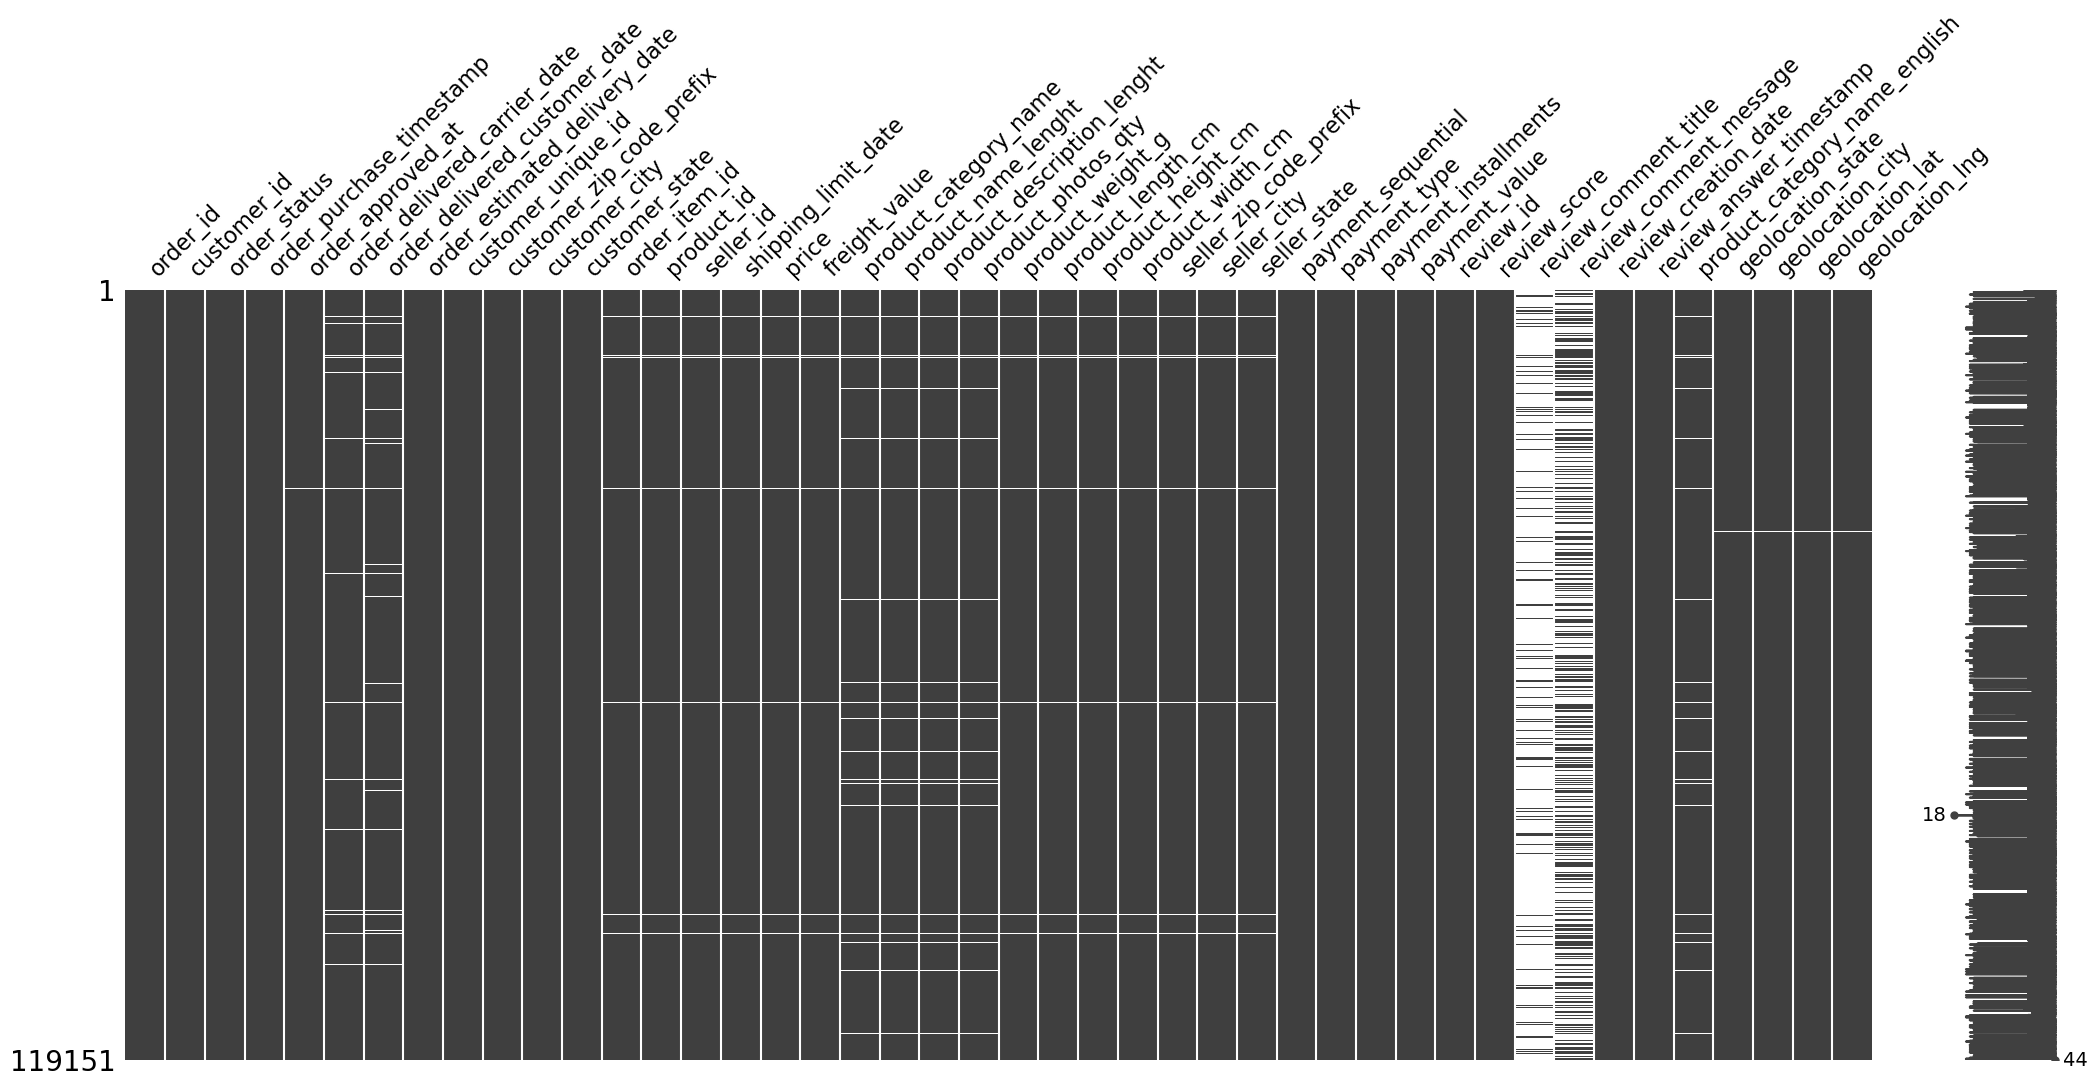

In [121]:
msno.matrix(Olist)

## Explore Key Categorical Columns

In [122]:
Olist['order_status'].value_counts()
Olist['payment_type'].value_counts()
Olist['review_score'].value_counts()
Olist['product_category_name_english'].value_counts().head(10)
Olist['customer_state'].value_counts().head(10)

customer_state
SP    50268
RJ    15518
MG    13819
RS     6574
PR     6043
SC     4345
BA     4092
DF     2516
GO     2466
ES     2360
Name: count, dtype: int64


### 1. What is the shape of the dataset (rows and columns)?

Use:
```python
Olist.shape


In [123]:
Olist.shape[0]

119151

* This returns the total number of rows (records) and columns (features) in the merged Olist dataset.

### 2) Which columns contain missing values?






In [124]:
Olist.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


#### Typical Missing Patterns in Olist:

* Delivery dates (order_delivered_customer_date, order_delivered_carrier_date)

* Item-level data for cancelled orders

 * Review comment fields

* Some seller/product fields

* Geolocation coordinates

* These missing values are meaningful and expected in real-world e-commerce data.

### 3. What are the data types of each column?

In [125]:
Olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119151 entries, 0 to 119150
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119151 non-null  object 
 1   customer_id                    119151 non-null  object 
 2   order_status                   119151 non-null  object 
 3   order_purchase_timestamp       119151 non-null  object 
 4   order_approved_at              118974 non-null  object 
 5   order_delivered_carrier_date   117065 non-null  object 
 6   order_delivered_customer_date  115730 non-null  object 
 7   order_estimated_delivery_date  119151 non-null  object 
 8   customer_unique_id             119151 non-null  object 
 9   customer_zip_code_prefix       119151 non-null  int64  
 10  customer_city                  119151 non-null  object 
 11  customer_state                 119151 non-null  object 
 12  order_item_id                 

#### Data Types Present:

* **object**: IDs, categories, city/state names, product category

* **int64**: review_score, installments, flags

* **float64** : prices, freight, weights, product dimensionsm

* **datetime64** : order timestamps, delivery dates, review timestamps

**Understanding data types helps in cleaning, parsing dates, and transforming features.**

### 4. What is the distribution of key fields?

In [126]:
Olist['order_status'].value_counts()
Olist['payment_type'].value_counts()
Olist['review_score'].value_counts()
Olist['customer_state'].value_counts().head(10)

customer_state
SP    50268
RJ    15518
MG    13819
RS     6574
PR     6043
SC     4345
BA     4092
DF     2516
GO     2466
ES     2360
Name: count, dtype: int64

#### Common Insights:

* Most orders are delivered

* Credit card is the most used payment method

* Review scores show a bimodal pattern **(many 1 Stars and 5 Stars)**

* SP, RJ, and MG are the top customer states

### Numeric Distributions

In [36]:
Olist[['price','freight_value','payment_value','delivery_days']].describe()

KeyError: "['delivery_days'] not in index"

### Common Insights:

* Strong right-skew in price and freight

* Delivery_days has a **long tail -> many delayed deliveries**

 * Payment_value varies widely depending on order size

### 5. Are there any data quality issues?

Yes,some issues appear, but they are normal for real marketplace data:

**a. Missing Values**

* Delivery dates missing for undelivered orders

* Missing review comments

* Missing product categories (“Unknown”)

**b. Outliers**

* Very high product prices

* Very heavy items

* High freight charges

  **These reflect real business diversity and are not removed.**

**c. Inconsistent Formatting**

* Product categories must be translated into English

* Review messages may contain blank strings

* Some datetime columns require conversion

**d. Duplicate order_id values**

**This is correct because one order can contain multiple items, payments, and reviews.**

In [127]:
Olist = Olist.drop(columns = ['product_category_name'], axis = 1)

# Phase 2: Data Cleaning & Manipulation

## Objective
The goal of this phase is to **clean and prepare the dataset** by resolving inconsistencies, handling missing values, and ensuring overall data quality.  
This stage also includes **non-visual bivariate analysis** to understand important relationships between key variables before generating visual insights.




## HANDLE MISSING VALUES

### Step 1: Identify Missing Values
The first step in data cleaning is to determine which columns contain missing or null values.  
This helps us understand how much information is incomplete and whether the missingness is meaningful (e.g., undelivered orders).

```python
Olist.isnull().sum()


In [128]:
Olist.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853
product_width_cm                    853


### A. For Numerical Columns

* Examples:
 price, freight_value, product_weight_g, product_height_cm

* Strategy:

**Fill missing values using median, as it is robust against outliers.**

**Justification:**
E-commerce datasets contain many extreme values; median provides a more stable representation than mean.

In [129]:
product_cols = [
    'product_description_lenght','product_photos_qty','product_weight_g',
    'product_length_cm','product_height_cm','product_width_cm'
]

for col in product_cols:
    Olist[col] = Olist[col].fillna(Olist[col].median())

### B. For Categorical Columns

### Examples:
**product_category_name_english,review_comment_title, review_comment_message**

**Strategy:**

* Fill missing values with Mode or a placeholder such as "Unknown".

**Justification:**
These fields are identifiers or labels, so using a placeholder avoids losing data.

In [130]:
## Filling the NaN values with 'No Comments'
Olist['review_comment_title'] = Olist['review_comment_title'].fillna("No Comment")

Olist['review_comment_message'] = Olist['review_comment_message'].fillna("No Comment")

Olist['product_category_name_english'] = Olist['product_category_name_english'].fillna("Unknown")


## Filling the Geolocation_state and Geolocation_city with 'Unknown'.

In [131]:
Olist['geolocation_state'] = Olist['geolocation_state'].fillna("Unknown")
Olist['geolocation_city'] = Olist['geolocation_city'].fillna("Unknown")

## Filling the Product_name_length with Median

In [132]:
Olist['product_name_lenght'] = Olist['product_name_lenght'].fillna(Olist['product_name_lenght'].median())

## Filling the Olist[['payment_sequential','payment_type','payment_installments','payment_value']] with Mode

In [133]:
Olist[['payment_sequential','payment_type','payment_installments','payment_value']].isna().sum()

payment_sequential      3
payment_type            3
payment_installments    3
payment_value           3
dtype: int64

In [134]:
fill_cols = ['payment_sequential', 'payment_type', 
             'payment_installments', 'payment_value']

for col in fill_cols:
    Olist[col] = Olist[col].fillna(Olist[col].mode()[0])

## Filling the Olist['geolocation_lat','geolocation_lng'] with "0" because They lat,lng are nan values. 

In [135]:
Olist['geolocation_lat'] = Olist['geolocation_lat'].fillna(0)
Olist['geolocation_lng'] = Olist['geolocation_lng'].fillna(0)


## 2. Remove Duplicates

### Step 1: Check for Duplicate Records
Before proceeding with analysis, it is important to check whether the dataset contains any **identical rows**.

```python
Olist.duplicated().sum()


In [136]:
Olist.duplicated("order_id").sum()

np.int64(19710)

### Remove Duplicate Rows (If Any)

* Olist = Olist.drop_duplicates()

### Important Note for Olist Dataset

* Duplicate order_id values are expected in Olist because:

**One order can have multiple items**

**One order can have multiple payments**

**One customer can write multiple review messages**

### Therefore:

**Do NOT remove duplicates based on order_id.**

**Only remove completely identical rows, if they exist.**

## 3. Fix Inconsistencies in Categorical Data
Ensures consistent formatting across all categorical fields.

```python
cat_cols = ['customer_city', 'customer_state', 'seller_city', 
            'seller_state', 'payment_type', 'order_status']

for col in cat_cols:
    Olist[col] = Olist[col].astype(str).str.lower().str.strip()


In [137]:
cat_cols = ['customer_city', 'customer_state', 'seller_city', 'seller_state', 'payment_type', 'order_status']

for col in cat_cols:
    Olist[col] = Olist[col].astype(str).str.lower().str.strip()

### Remove Extra Spaces or Special Characters

In [138]:
Olist['product_category_name_english'] = (Olist['product_category_name_english'].astype(str).str.strip())

### Standardize Category Names

In [139]:
Olist['product_category_name_english'] = (Olist['product_category_name_english'].replace({
        'fashon_bags': 'fashion_bags',
        'sports-leisure': 'sports_leisure',
        'Unknown': 'unknown' }))


## 4. Convert Data Types



```python
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    Olist[col] = pd.to_datetime(Olist[col], errors='coerce')


In [140]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp']

for col in date_cols:
    Olist[col] = pd.to_datetime(Olist[col], errors='coerce')

### Convert Numeric Columns Stored as Strings

In [141]:
numeric_fix_cols = [
    'price', 'freight_value', 'payment_value',
    'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm'
]

for col in numeric_fix_cols:
    Olist[col] = pd.to_numeric(Olist[col], errors='coerce')


In [142]:
Olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119151 entries, 0 to 119150
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119151 non-null  object        
 1   customer_id                    119151 non-null  object        
 2   order_status                   119151 non-null  object        
 3   order_purchase_timestamp       119151 non-null  datetime64[ns]
 4   order_approved_at              118974 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117065 non-null  datetime64[ns]
 6   order_delivered_customer_date  115730 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119151 non-null  datetime64[ns]
 8   customer_unique_id             119151 non-null  object        
 9   customer_zip_code_prefix       119151 non-null  int64         
 10  customer_city                  119151 non-null  object        
 11  

### Convert Categorical Columns to Category Type

In [143]:
cat_cols = ['customer_state', 'seller_state','payment_type', 'order_status','product_category_name_english']
for col in cat_cols:
    Olist[col] = Olist[col].astype('category')

## Benefits:

**Reduces memory usage**

**Improves speed for grouping and filtering**

**Makes analysis more efficient**

## "Adding the colunm for analysis on the delivery_days"

In [149]:
Olist['delivery_days'] = (Olist['order_delivered_customer_date'] - Olist['order_purchase_timestamp']).dt.days

In [150]:
Olist['delivery_days'] = Olist['delivery_days'].astype('Int64')

## For checking delivery recevied are not 

In [151]:
Olist['delivered_flag'] = np.where(Olist['delivery_days'].isna(), 0, 1)

In [152]:
order_level = Olist.groupby('order_id').agg({'price':'sum','freight_value':'sum','review_score':'max','customer_id':'first','order_purchase_timestamp':'first'})
order_level

,price,freight_value,review_score,customer_id,order_purchase_timestamp
order_id,,,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,5,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,4,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06
000229ec398224ef6ca0657da4fc703e,199.00,17.87,5,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,4,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,5,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51
...,...,...,...,...,...
fffc94f6ce00a00581880bf54a75a037,299.99,43.41,5,b51593916b4b8e0d6f66f2ae24f2673d,2018-04-23 13:57:06
fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,5,84c5d4fbaf120aae381fad077416eaa0,2018-07-14 10:26:46
fffce4705a9662cd70adb13d4a31832d,99.90,16.95,5,29309aa813182aaddc9b259e31b870e6,2017-10-23 17:07:56


In [153]:
# Late delivery flag (only for delivered orders)
Olist['late_delivery_flag'] = np.where((Olist['order_delivered_customer_date'].notna()) & (Olist['order_delivered_customer_date'] > Olist['order_estimated_delivery_date']),1, 0)

In [154]:
# Simple revenue per item
Olist['revenue'] = Olist['price'] + Olist['freight_value']

In [147]:
# Remove duplicate column names
Olist = Olist.loc[:, ~Olist.columns.duplicated()]

# Remove unwanted spaces
Olist.columns = Olist.columns.str.strip()

# Save safelyOlist
Olist.to_csv("olist1_final_mysql1.csv", index=False)


In [155]:
Olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119151 entries, 0 to 119150
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119151 non-null  object        
 1   customer_id                    119151 non-null  object        
 2   order_status                   119151 non-null  category      
 3   order_purchase_timestamp       119151 non-null  datetime64[ns]
 4   order_approved_at              118974 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117065 non-null  datetime64[ns]
 6   order_delivered_customer_date  115730 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119151 non-null  datetime64[ns]
 8   customer_unique_id             119151 non-null  object        
 9   customer_zip_code_prefix       119151 non-null  int64         
 10  customer_city                  119151 non-null  object        
 11  

In [106]:
Olist.to_csv("Slist.csv",index = False)

## 5. Non-Visual Bivariate Analysis

### **A. Categorical vs Categorical**
Compare group-wise counts or proportions to understand how categories interact.

#### Example 1: Late Delivery vs Review Score
```python
pd.crosstab(Olist['review_score'], Olist['late_delivery_flag'])


In [60]:
pd.crosstab(Olist['review_score'], Olist['late_delivery_flag'])

late_delivery_flag,0,1
review_score,,
1,11715,4301
2,3567,713
3,9019,1000
4,21297,1089
5,64485,1965


In [61]:
pd.crosstab(Olist['payment_type'], Olist['order_status'])

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0,112,2,22505,96,97,226,152
credit_card,3,513,3,85383,262,254,922,447
debit_card,0,7,0,1662,6,2,23,6
not_defined,0,3,0,0,0,0,0,0
voucher,0,115,0,6181,14,23,85,47


## B. Categorical vs Numerical

In [62]:
Olist.groupby('review_score')['delivery_days'].mean()

review_score
1    19.109397
2    15.446968
3     13.57115
4    11.784666
5    10.208818
Name: delivery_days, dtype: Float64

In [64]:
Olist.to_csv("Vlist.csv",index = False)

In [66]:
Olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119151 entries, 0 to 119150
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119151 non-null  object        
 1   customer_id                    119151 non-null  object        
 2   order_status                   119151 non-null  category      
 3   order_purchase_timestamp       119151 non-null  datetime64[ns]
 4   order_approved_at              118974 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117065 non-null  datetime64[ns]
 6   order_delivered_customer_date  115730 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119151 non-null  datetime64[ns]
 8   customer_unique_id             119151 non-null  object        
 9   customer_zip_code_prefix       119151 non-null  int64         
 10  customer_city                  119151 non-null  object        
 11  

In [63]:
Olist.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 177
order_delivered_carrier_date     2086
order_delivered_customer_date    3421
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     833
product_id                        833
seller_id                         833
shipping_limit_date               833
price                             833
freight_value                     833
product_category_name            2542
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
seller_zip_c

In [47]:
Olist.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False).head(10)

customer_state
pb    43.228984
rr    42.984423
ro    40.970175
ac    40.021684
to    39.677286
pi    39.201847
ma    38.200931
se    36.627935
al    35.643680
pa    35.634600
Name: freight_value, dtype: float64

In [48]:
Olist.groupby('product_category_name_english')['price'].mean().sort_values(ascending=False).head(10)


product_category_name_english
computers                                1103.689136
small_appliances_home_oven_and_coffee     627.509103
home_appliances_2                         457.390258
agro_industry_and_commerce                332.706151
musical_instruments                       293.398651
small_appliances                          286.297248
fixed_telephony                           226.989890
construction_tools_safety                 210.942261
watches_gifts                             201.886842
air_conditioning                          185.305894
Name: price, dtype: float64

## C. Numerical vs Numerical

In [49]:
Olist[['price', 'freight_value']].corr()

,price,freight_value
price,1.000000,0.415944
freight_value,0.415944,1.000000


In [50]:
Olist[['payment_value', 'payment_installments']].corr()

,payment_value,payment_installments
payment_value,1.000000,0.273663
payment_installments,0.273663,1.000000


In [51]:
Olist[['product_weight_g', 'freight_value']].corr()

,product_weight_g,freight_value
product_weight_g,1.000000,0.611598
freight_value,0.611598,1.000000


# UNIVARIATE ANALYSIS:

### Summary Statistics

In [53]:
Olist.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 177
order_delivered_carrier_date     2086
order_delivered_customer_date    3421
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     833
product_id                        833
seller_id                         833
shipping_limit_date               833
price                             833
freight_value                     833
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
seller_zip_code_prefix            833
seller_city 

In [52]:
num_cols = ['price','freight_value','payment_value','payment_installments',
    'delivery_days','product_weight_g','product_length_cm',
    'product_height_cm','product_width_cm']
Olist[num_cols].describe()

,price,freight_value,payment_value,payment_installments,delivery_days,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,118318.000000,118318.000000,119151.00000,119151.000000,115730.0,119151.000000,119151.000000,119151.000000,119151.000000
mean,120.649109,20.032587,172.73258,2.941377,12.023019,2102.192151,30.227174,16.594078,23.052882
std,184.107686,15.836559,267.76736,2.777975,9.454891,3774.973415,16.137045,13.409000,11.709954
min,0.850000,0.000000,0.00000,0.000000,0.0,0.000000,7.000000,2.000000,6.000000
25%,39.900000,13.080000,60.85000,1.000000,6.0,300.000000,18.000000,8.000000,15.000000
50%,74.900000,16.280000,108.15000,2.000000,10.0,700.000000,25.000000,13.000000,20.000000
75%,134.900000,21.180000,189.24000,4.000000,15.0,1800.000000,38.000000,20.000000,30.000000
max,6735.000000,409.680000,13664.08000,24.000000,209.0,40425.000000,105.000000,105.000000,118.000000


## Distribution Plots (Histogram + KDE)

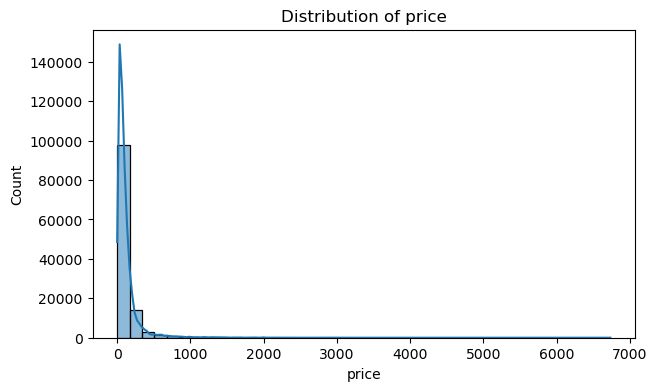

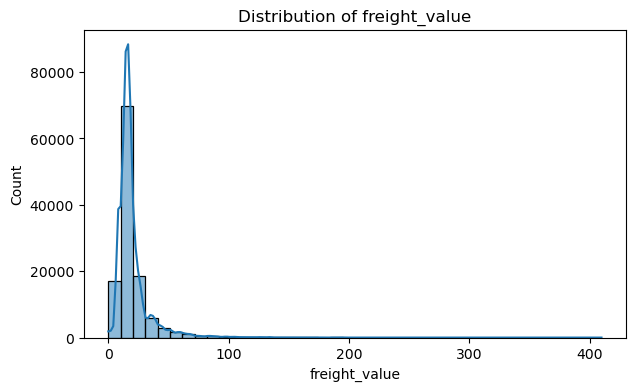

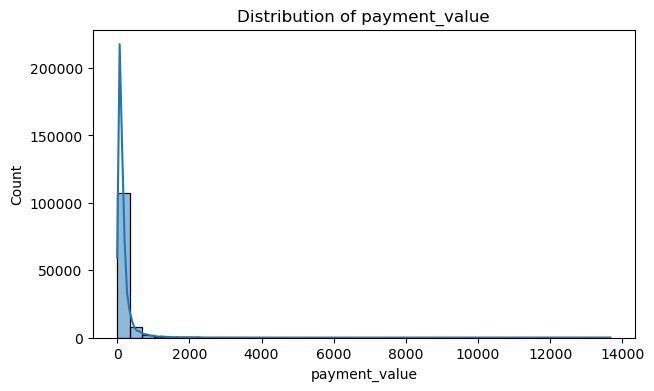

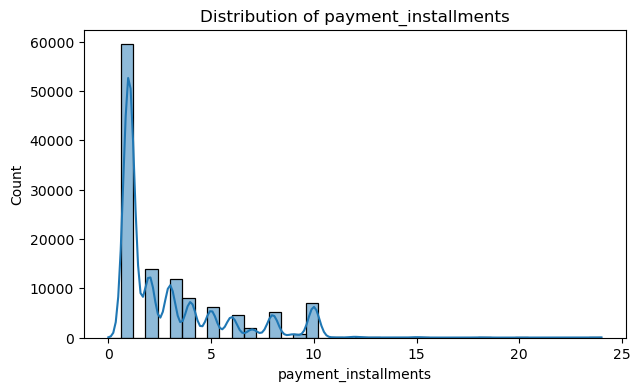

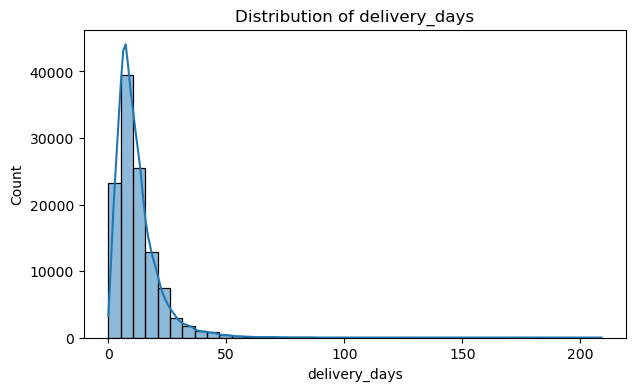

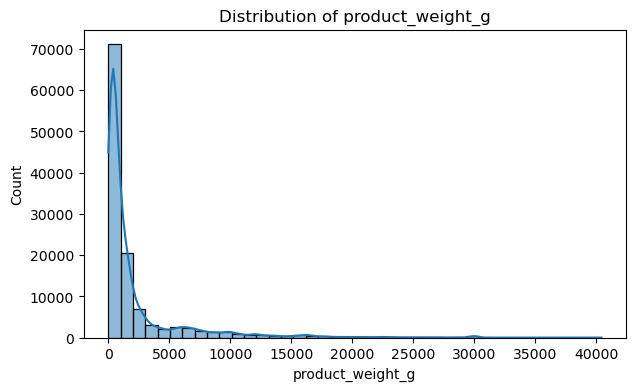

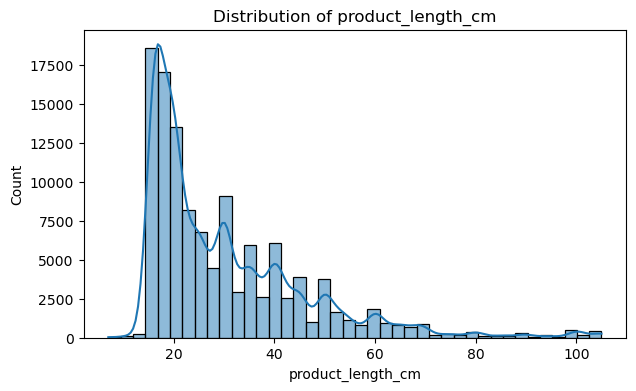

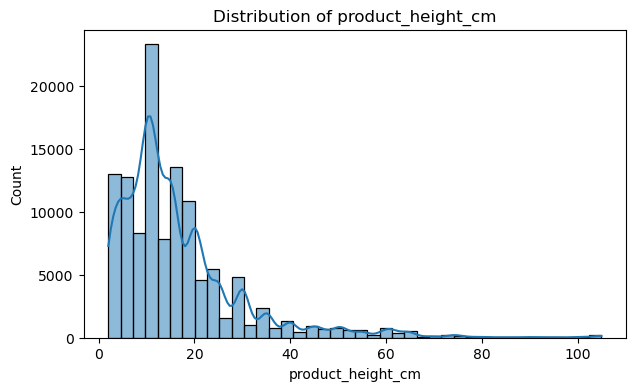

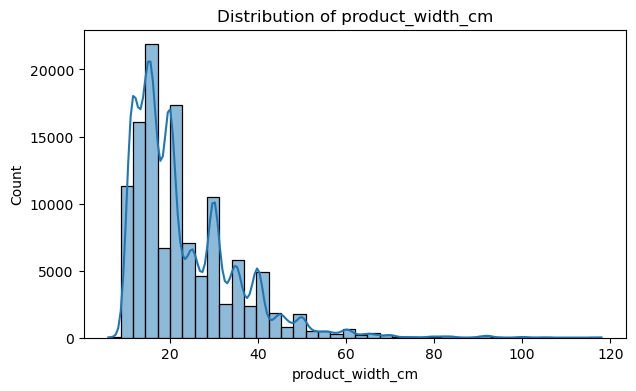

In [203]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(Olist[col].dropna(), kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.show()

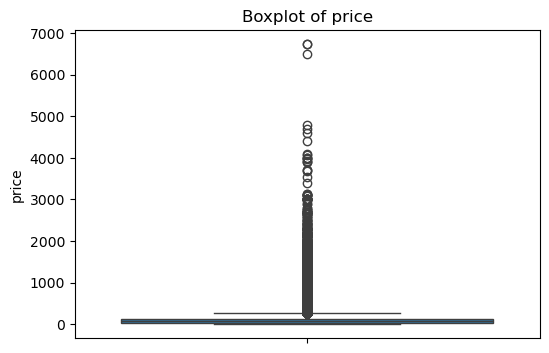

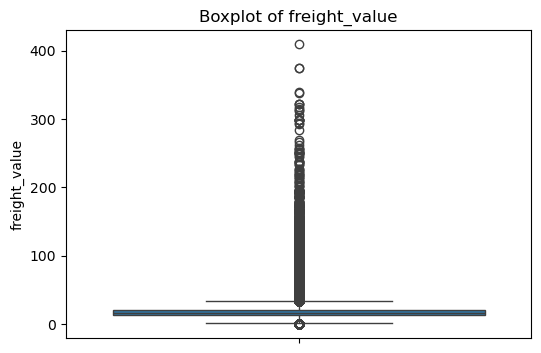

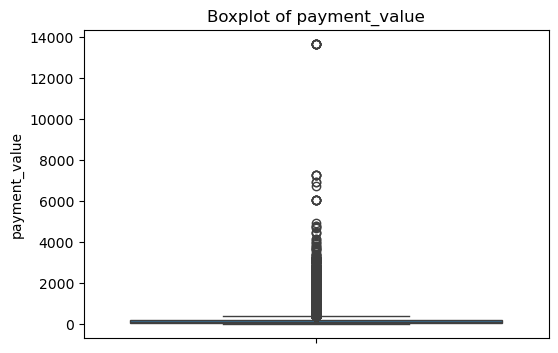

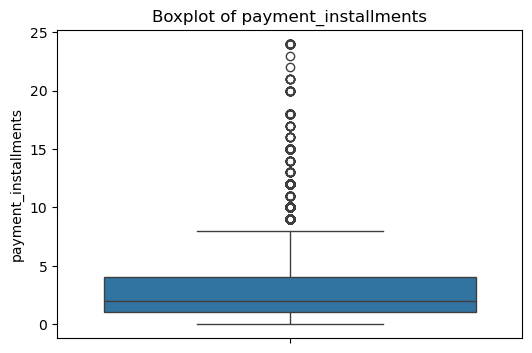

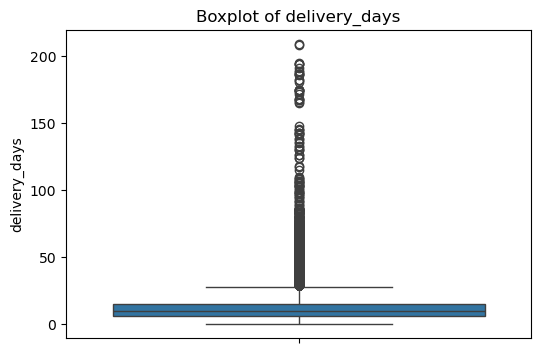

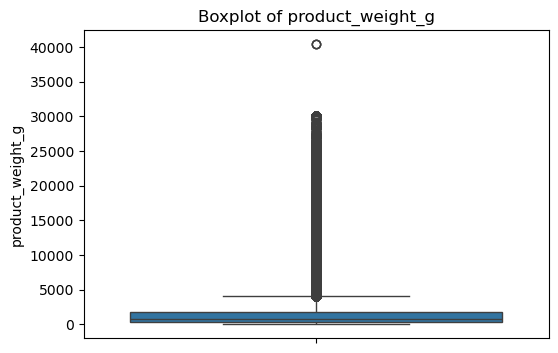

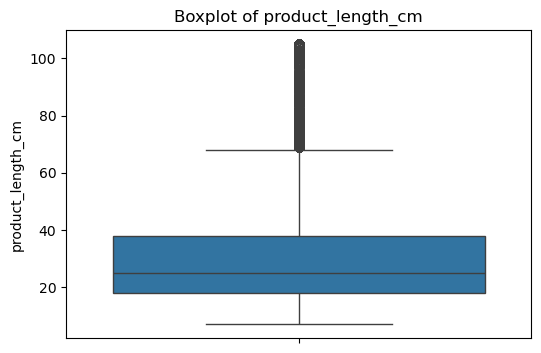

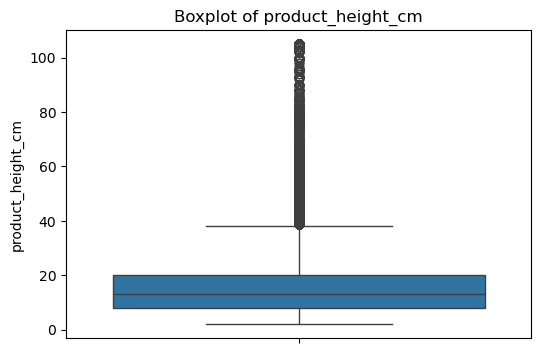

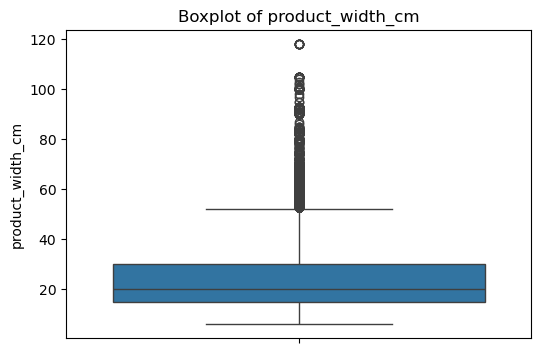

In [204]:
product_cols = [
    'price','freight_value','payment_value','payment_installments',
    'delivery_days','product_weight_g','product_length_cm',
    'product_height_cm','product_width_cm'
]

for col in product_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=Olist[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Frequency Count (Categorical)


Value Counts for order_status:
order_status
delivered      115731
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64


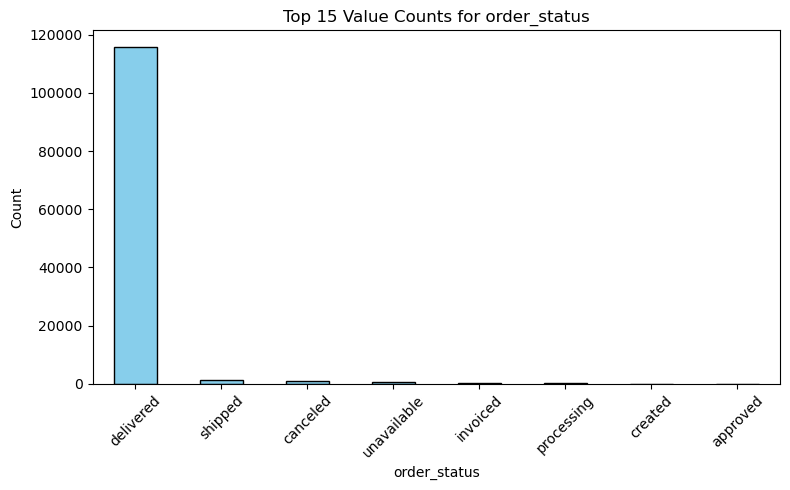

**************************************************

Value Counts for customer_state:
customer_state
SP    50268
RJ    15518
MG    13819
RS     6574
PR     6043
SC     4345
BA     4092
DF     2516
GO     2466
ES     2360
PE     1908
CE     1565
MT     1132
PA     1130
MS      862
Name: count, dtype: int64


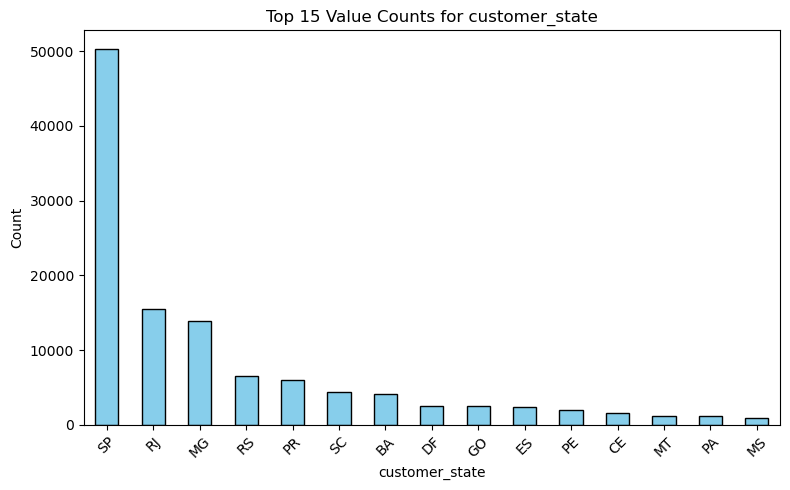

**************************************************

Value Counts for payment_type:
payment_type
credit_card    87784
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64


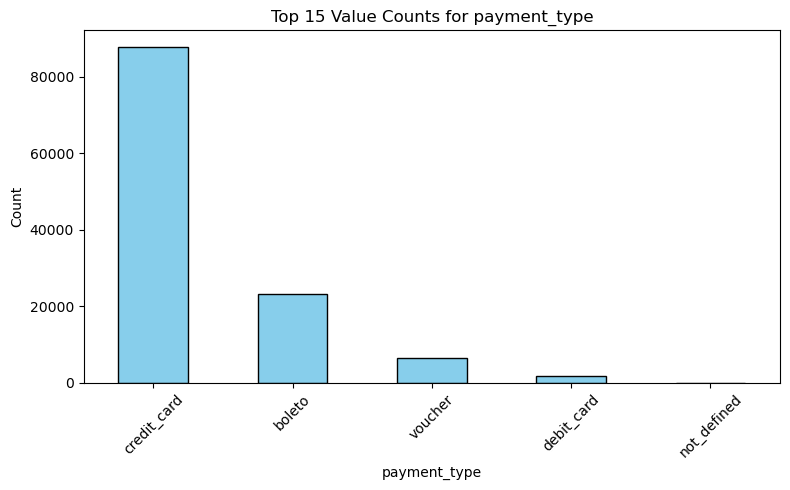

**************************************************

Value Counts for review_score:
review_score
5    66450
4    22386
1    16016
3    10019
2     4280
Name: count, dtype: int64


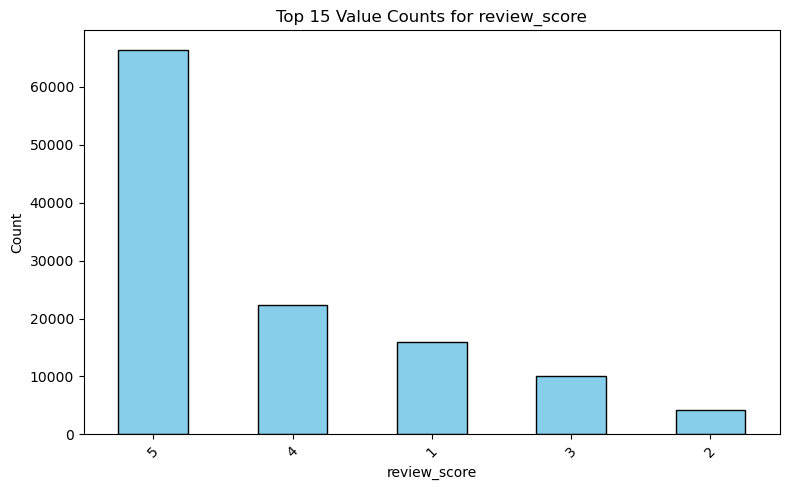

**************************************************

Value Counts for product_category_name_english:
product_category_name_english
bed_bath_table           11990
health_beauty            10033
sports_leisure            9005
furniture_decor           8833
computers_accessories     8151
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
toys                      4281
cool_stuff                3999
perfumery                 3589
baby                      3204
electronics               2847
Name: count, dtype: int64


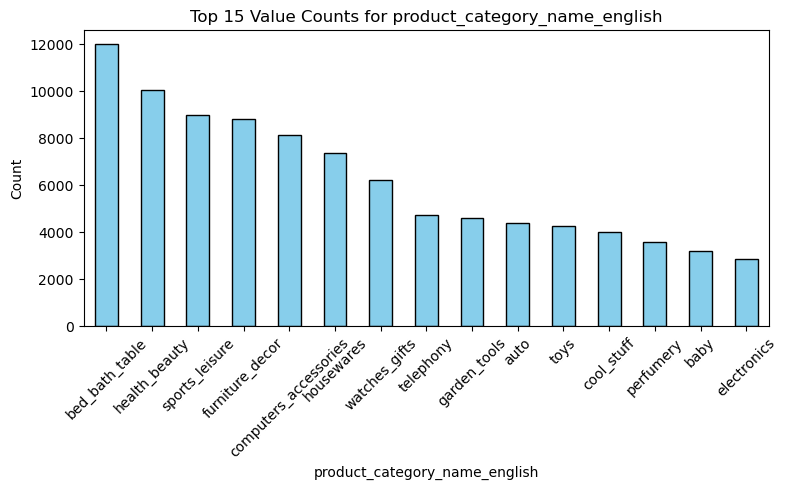

**************************************************

Value Counts for seller_state:
seller_state
SP    84384
MG     9314
PR     9097
RJ     5036
SC     4271
RS     2294
DF      949
BA      700
GO      550
PE      465
MA      410
ES      390
MT      147
CE      103
MS       60
Name: count, dtype: int64


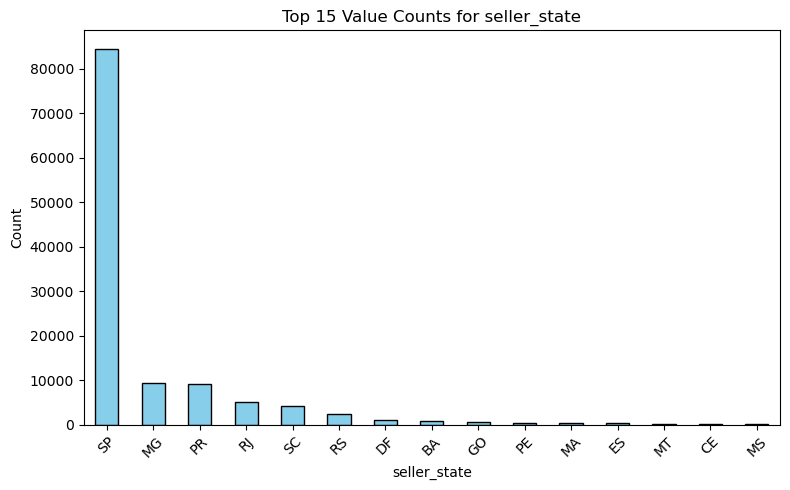

**************************************************


In [206]:
cat_cols = ['order_status','customer_state','payment_type','review_score','product_category_name_english','seller_state']
for col in cat_cols:
    print(f"\nValue Counts for {col}:")
    print(Olist[col].value_counts().head(15))
    plt.figure(figsize=(8,5))
    Olist[col].value_counts().head(15).plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Top 15 Value Counts for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("*" * 50)

## UNIVARIATE ANALYSIS — Categorical Columns (Countplots)

### order_status

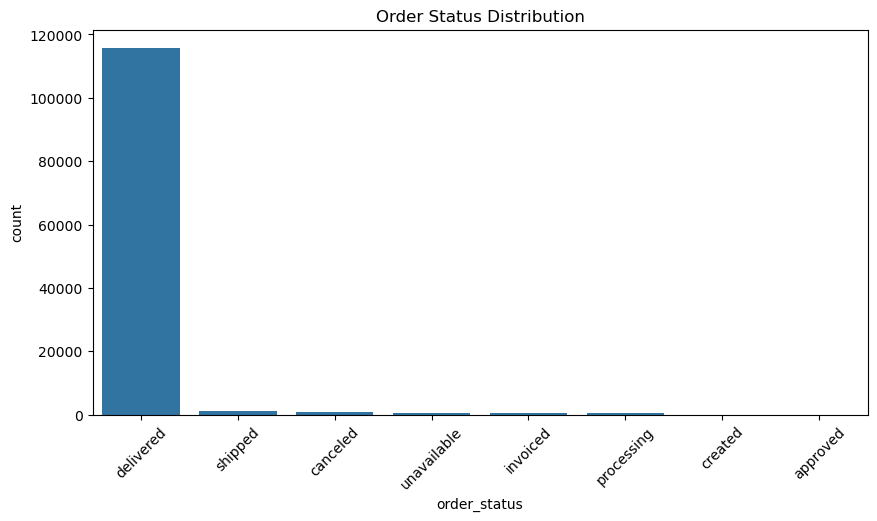

In [207]:
plt.figure(figsize=(10,5))
sns.countplot(data=Olist, x='order_status', order=Olist['order_status'].value_counts().index)
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

* Most orders are delivered.
* Very few are canceled → but important for operations.

## review_score

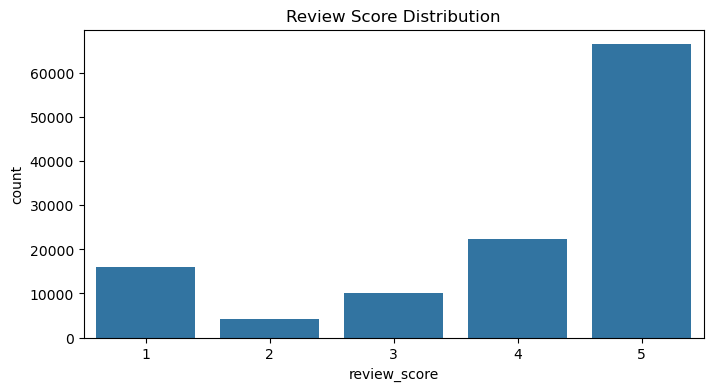

In [208]:
plt.figure(figsize=(8,4))
sns.countplot(data=Olist, x='review_score', order=sorted(Olist['review_score'].unique()))
plt.title("Review Score Distribution")
plt.show()

* Bimodal distribution: Many 5-star and 1-star reviews.
* Indicates customer experience polarization.

## payment_type

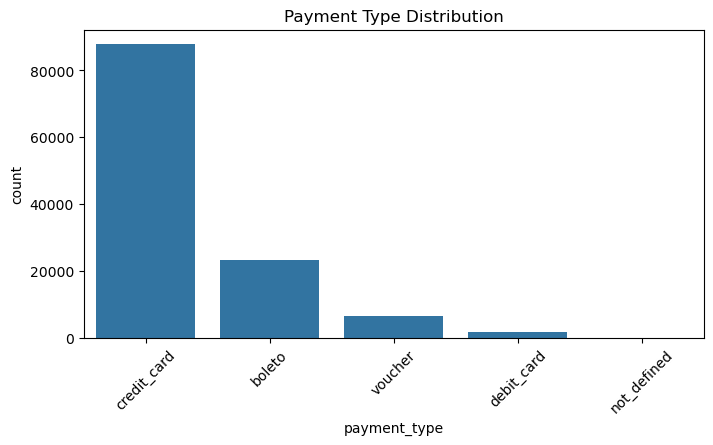

In [209]:
plt.figure(figsize=(8,4))
sns.countplot(data=Olist, x='payment_type', order=Olist['payment_type'].value_counts().index)
plt.title("Payment Type Distribution")
plt.xticks(rotation=45)
plt.show()

* Credit card is the dominant payment method.
* Boleto (bank slip) is second most used.

## customer_state

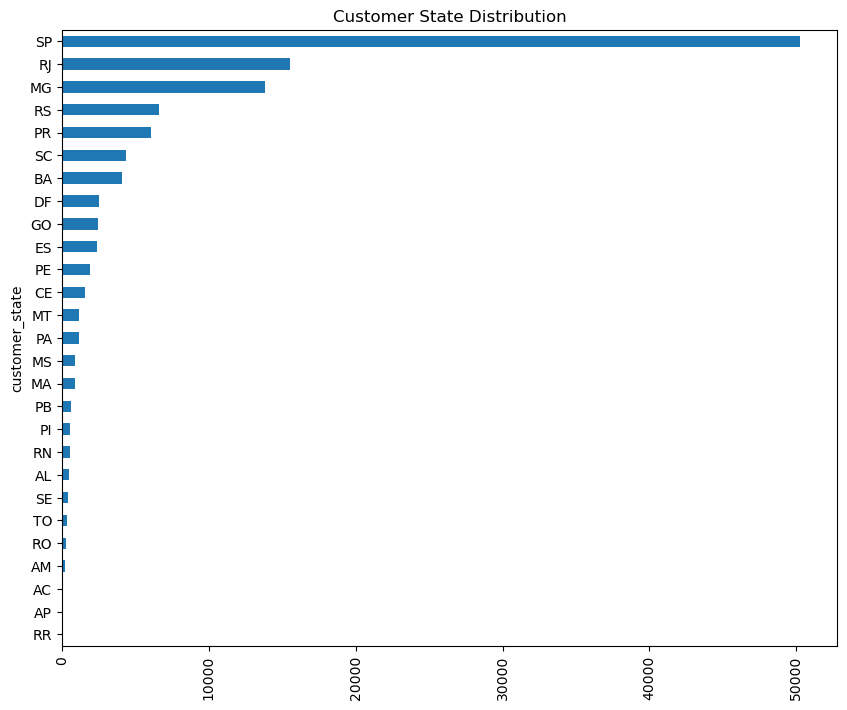

In [210]:
plt.figure(figsize=(10,8))
Olist['customer_state'].value_counts().sort_values(ascending = True).plot(kind = 'barh')
plt.title("Customer State Distribution")
plt.xticks(rotation=90)
plt.show()

* SP (São Paulo) dominates: main e-commerce region.
* Useful for geographic analysis.




## product_category_name_english

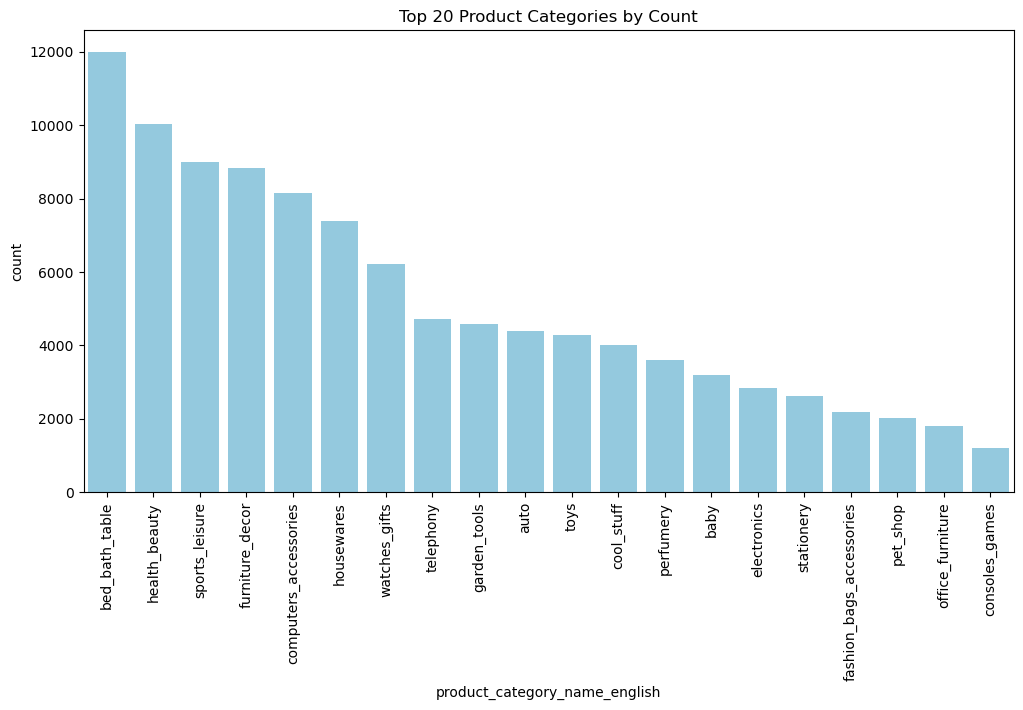

In [211]:
plt.figure(figsize=(12,6))
top20 = Olist['product_category_name_english'].value_counts().head(20).index
sns.countplot(data=Olist, x='product_category_name_english', order=top20, color="skyblue")
plt.title("Top 20 Product Categories by Count")
plt.xticks(rotation=90)
plt.show()

* Categories likem “bed_bath_table”, “health_beauty”, “sports_leisure” appear most.
* Long tail : many categories with low volume.

## seller_state

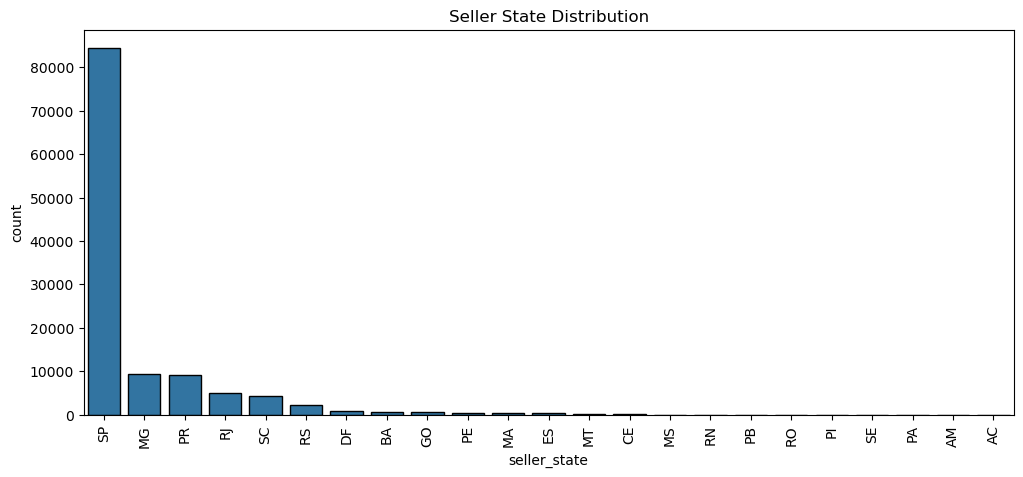

In [212]:
plt.figure(figsize=(12,5))
sns.countplot(data=Olist, x='seller_state', order=Olist['seller_state'].value_counts().index,edgecolor="black")
plt.title("Seller State Distribution")
plt.xticks(rotation=90)
plt.show()

## customer_city

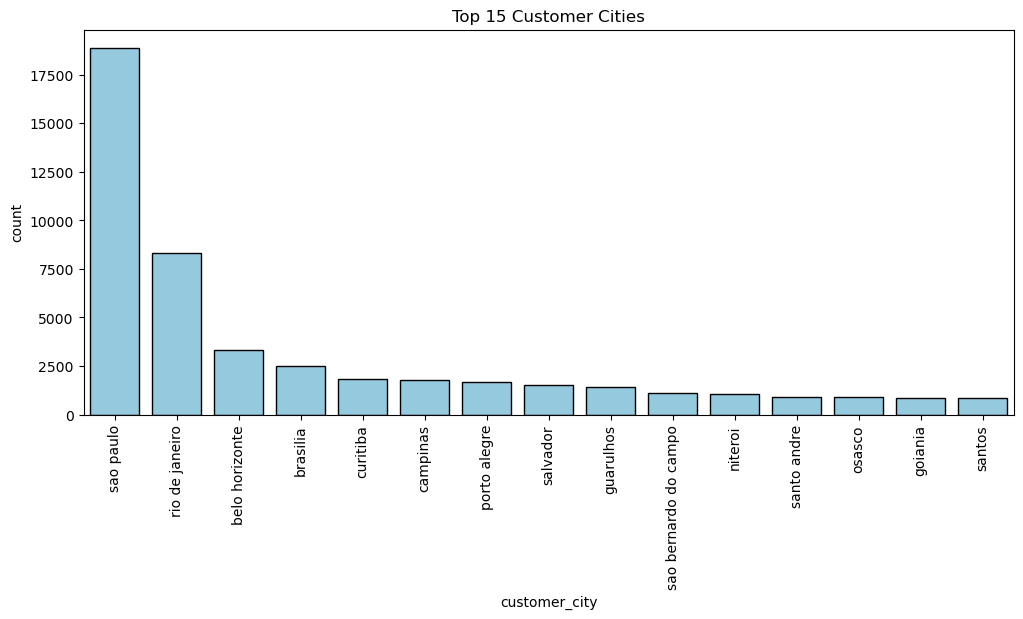

In [213]:
plt.figure(figsize=(12,5))
top15_cities = Olist['customer_city'].value_counts().head(15).index
sns.countplot(data=Olist, x='customer_city', order=top15_cities,color="skyblue",edgecolor="black")
plt.title("Top 15 Customer Cities")
plt.xticks(rotation=90)
plt.show()

## seller_city

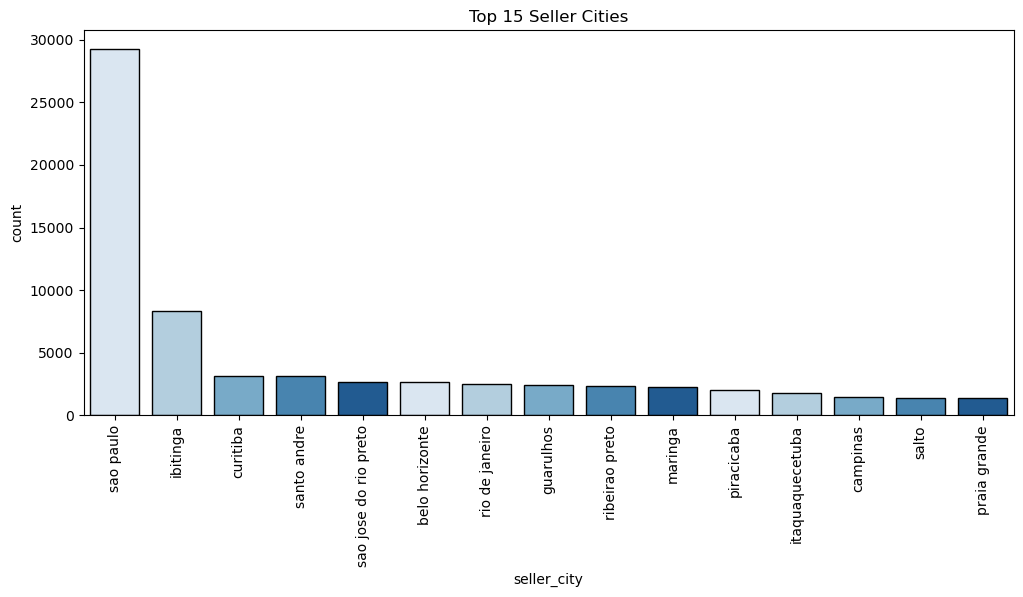

In [214]:
plt.figure(figsize=(12,5))
top15_seller_cities = Olist['seller_city'].value_counts().head(15).index
sns.countplot(data=Olist, x='seller_city', order=top15_seller_cities,palette = sns.color_palette("Blues", n_colors=5),edgecolor="black")
plt.title("Top 15 Seller Cities")
plt.xticks(rotation=90)
plt.show()

## product_photos_qty

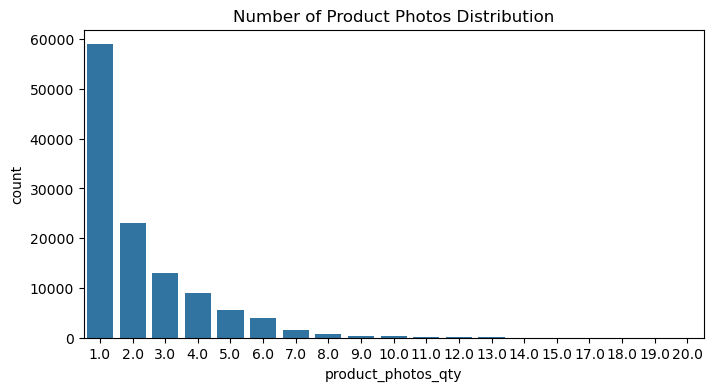

In [215]:
plt.figure(figsize=(8,4))
sns.countplot(data=Olist, x='product_photos_qty', order=sorted(Olist['product_photos_qty'].dropna()))
plt.title("Number of Product Photos Distribution")
plt.show()

## What percentage of orders are delivered late

In [216]:
late_delivered = Olist[Olist['delivered_flag'] == 1]['late_delivery_flag'].mean() * 100
late_delivered

np.float64(7.835479132463492)

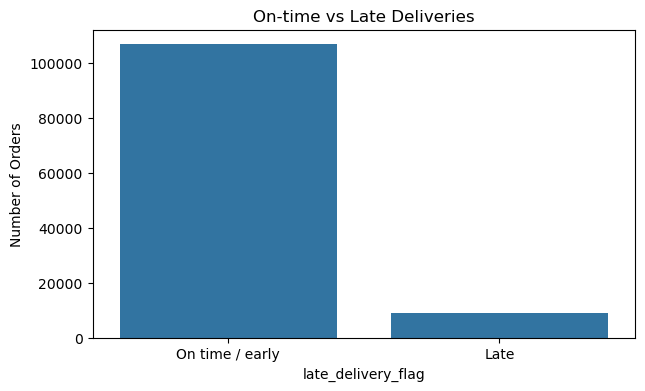

In [217]:
plt.figure(figsize=(7,4))
sns.countplot(x='late_delivery_flag', data=Olist[Olist['delivered_flag'] == 1])
plt.xticks([0,1], ['On time / early', 'Late'])
plt.title("On-time vs Late Deliveries")
plt.ylabel("Number of Orders")
plt.show()

## Insight: 
 * This gives a % like “X% of delivered orders are late”, directly tied to service quality.

# BIVARIATE ANALYSIS

### Price vs Freight Value (Shipping Cost)

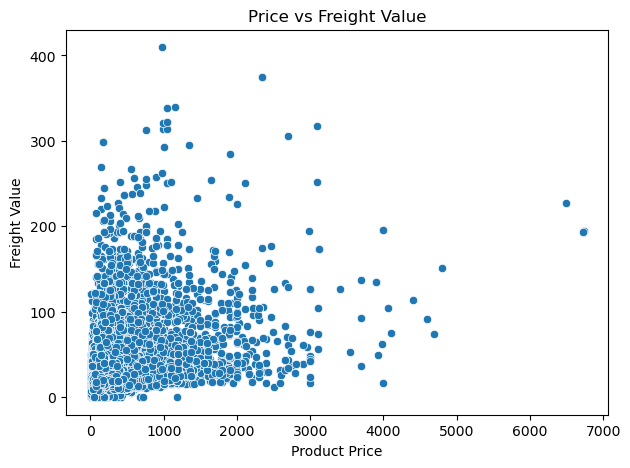

In [218]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=Olist, x='price', y='freight_value')
plt.title("Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.show()

* Insight: Higher prices usually → higher freight due to product weight & size.

## Product Weight vs Freight Value

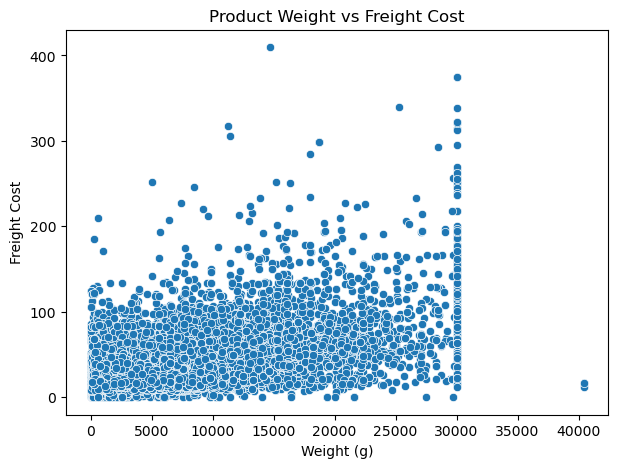

In [219]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=Olist, x='product_weight_g', y='freight_value')
plt.title("Product Weight vs Freight Cost")
plt.xlabel("Weight (g)")
plt.ylabel("Freight Cost")
plt.show()


* Insight: Heavy items cost more to ship → logistics cost driver.

## Payment Value vs Installments

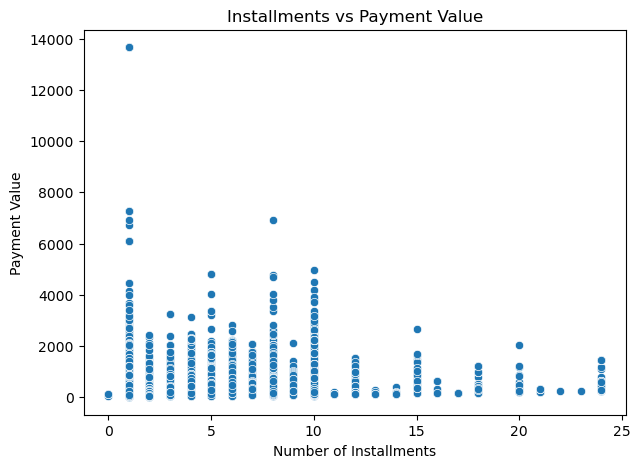

In [220]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=Olist, x='payment_installments', y='payment_value')
plt.title("Installments vs Payment Value")
plt.xlabel("Number of Installments")
plt.ylabel("Payment Value")
plt.show()

* Insight: Big purchases → more installments (positive relationship).

### avg delivery_days by review_score

In [221]:
Olist[Olist['delivery_days'].notna()].groupby('review_score')['delivery_days'].mean().sort_index()

review_score
1    19.109397
2    15.446968
3     13.57115
4    11.784666
5    10.208818
Name: delivery_days, dtype: Float64

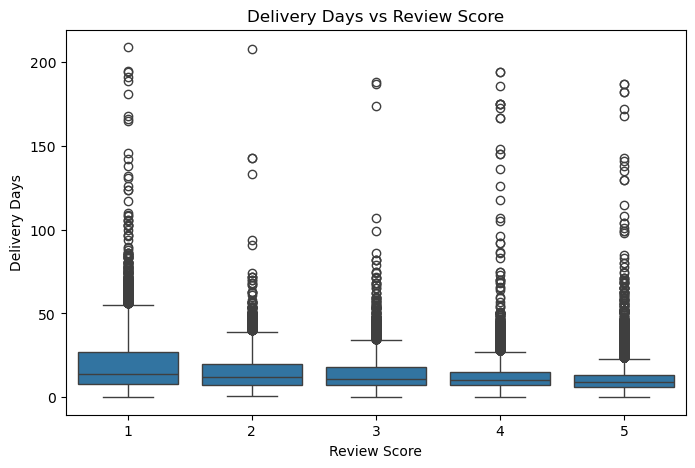

In [156]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Olist, x='review_score', y='delivery_days')
plt.title("Delivery Days vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.show()

## Insight: 
  * Usually see 1-star reviews with much higher delivery_days → strong evidence that late delivery hurts satisfaction.

## Categorical vs Numerical

### Which states/cities have the longest delivery delays?

In [223]:
state_delay = (Olist[Olist['delivery_days'].notna()].groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False))
state_delay.head(10)

customer_state
RR    27.826087
AP    27.662651
AM    26.064706
AL     24.12809
PA     23.26867
MA    21.191981
SE     20.88601
CE    20.344415
AC    20.170213
PB    20.107372
Name: delivery_days, dtype: Float64

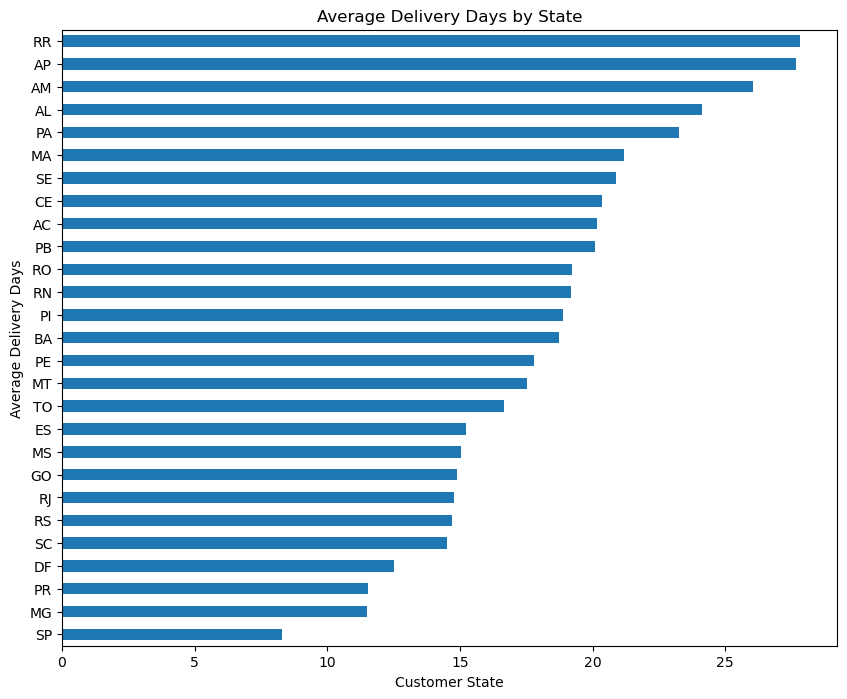

In [224]:
plt.figure(figsize=(10,8))
state_delay.sort_values(ascending=True).plot(kind='barh')
plt.title("Average Delivery Days by State")
plt.xlabel("Customer State")
plt.ylabel("Average Delivery Days")
plt.show()

## Insight: 
* States with highest avg delivery_days are your worst-served regions often remote states.

## Customer State vs Delivery Days (Top 10 states only)

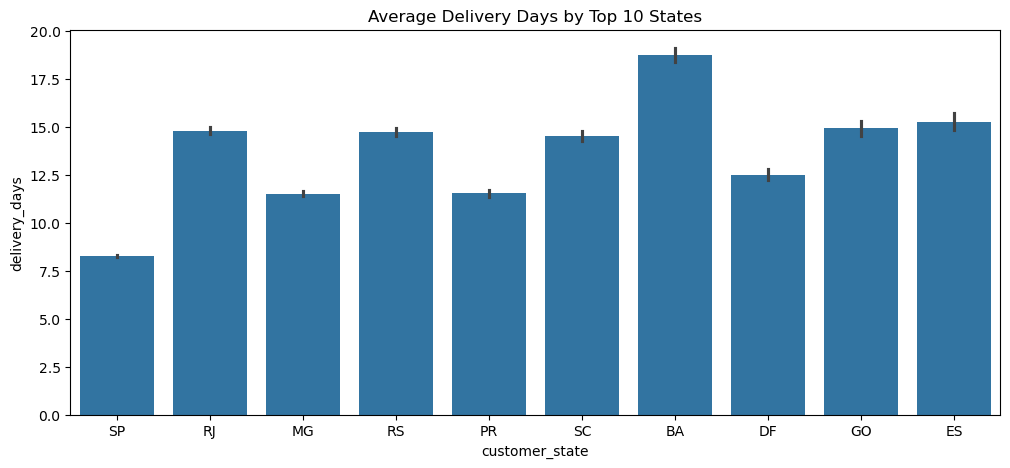

In [225]:
top_states = Olist['customer_state'].value_counts().head(10).index
plt.figure(figsize=(12,5))
sns.barplot(data=Olist[Olist['customer_state'].isin(top_states)],
            x='customer_state', y='delivery_days',order = top_states)
plt.title("Average Delivery Days by Top 10 States")
plt.show()

* Insight: Remote states show higher delivery time.

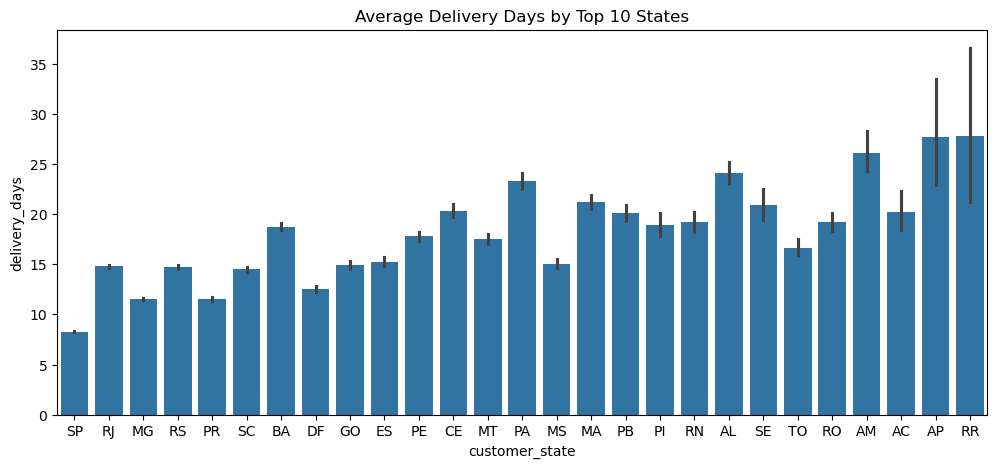

In [226]:
top_states = Olist['customer_state'].value_counts().tail(30).index
plt.figure(figsize=(12,5))
sns.barplot(data=Olist[Olist['customer_state'].isin(top_states)],
            x='customer_state', y='delivery_days',order = top_states)
plt.title("Average Delivery Days by Top 10 States")
plt.show()

## Product Category vs Review Score (Top 20 categories)

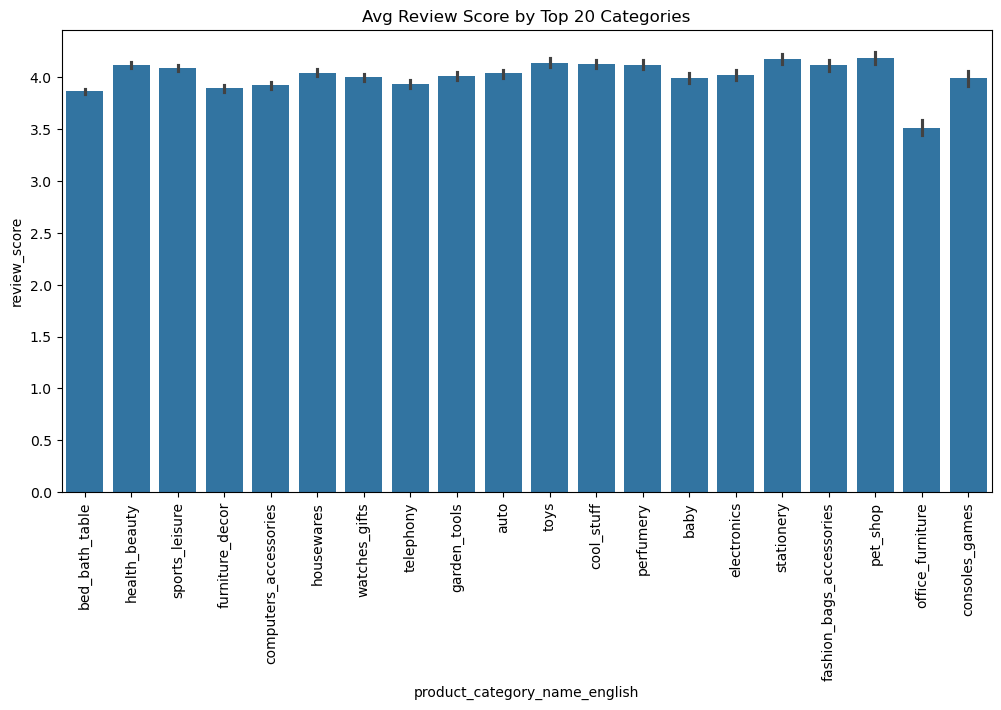

In [227]:
top20 = Olist['product_category_name_english'].value_counts().head(20).index
plt.figure(figsize=(12,6))
sns.barplot(data=Olist[Olist['product_category_name_english'].isin(top20)],
            x='product_category_name_english', y='review_score',order = top20)
plt.title("Avg Review Score by Top 20 Categories")
plt.xticks(rotation=90)
plt.show()

* Insight: Some categories consistently get bad reviews → quality/logistics issue.

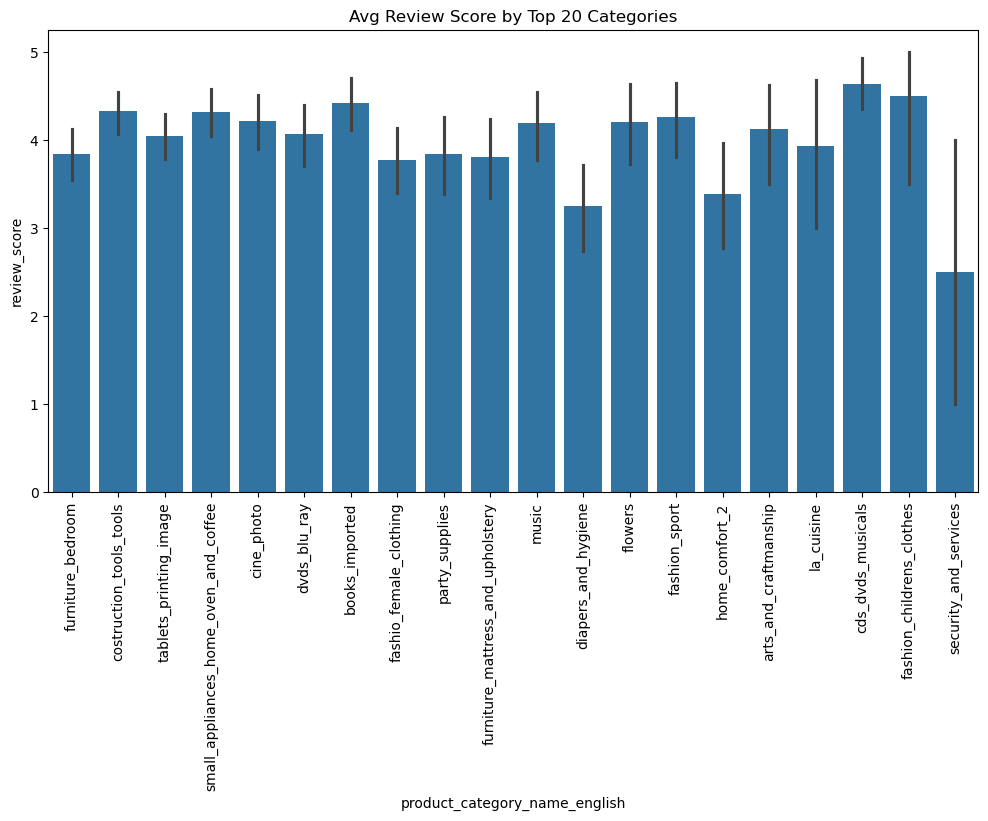

In [228]:
top20 = Olist['product_category_name_english'].value_counts().tail(20).index
plt.figure(figsize=(12,6))
sns.barplot(data=Olist[Olist['product_category_name_english'].isin(top20)],
            x='product_category_name_english', y='review_score',order = top20)
plt.title("Avg Review Score by Top 20 Categories")
plt.xticks(rotation=90)
plt.show()

## Payment Type vs Payment Value

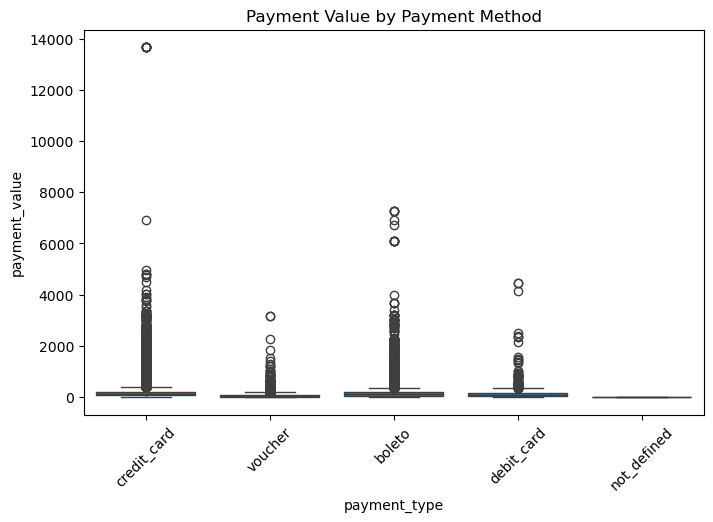

In [229]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Olist, x='payment_type', y='payment_value')
plt.title("Payment Value by Payment Method")
plt.xticks(rotation=45)
plt.show()


* Insight: Credit card purchases usually have higher payment value.

### Which product categories have the best & worst ratings?

In [158]:
cat_reviews = (Olist.groupby('product_category_name_english')['review_score'].mean().sort_values())
cat_reviews.head(10), cat_reviews.tail(10)

(product_category_name_english
 security_and_services                2.500000
 unknown                              3.139462
 diapers_and_hygiene                  3.256410
 home_comfort_2                       3.387097
 office_furniture                     3.516779
 fashion_male_clothing                3.531034
 fixed_telephony                      3.661765
 fashio_female_clothing               3.780000
 furniture_mattress_and_upholstery    3.804878
 audio                                3.824147
 Name: review_score, dtype: float64,
 product_category_name_english
 fashion_sport                            4.258065
 luggage_accessories                      4.290628
 food_drink                               4.312715
 small_appliances_home_oven_and_coffee    4.320513
 costruction_tools_tools                  4.333333
 books_technical                          4.345588
 books_imported                           4.419355
 books_general_interest                   4.431858
 fashion_childrens_clot

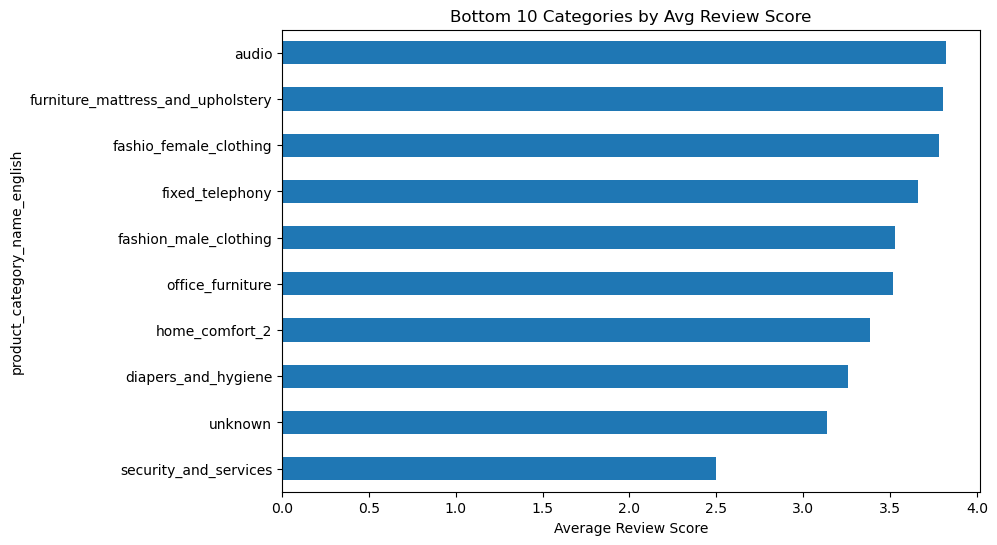

In [159]:
plt.figure(figsize=(9,6))
cat_reviews.head(10).plot(kind='barh')
plt.title("Bottom 10 Categories by Avg Review Score")
plt.xlabel("Average Review Score")
plt.show()

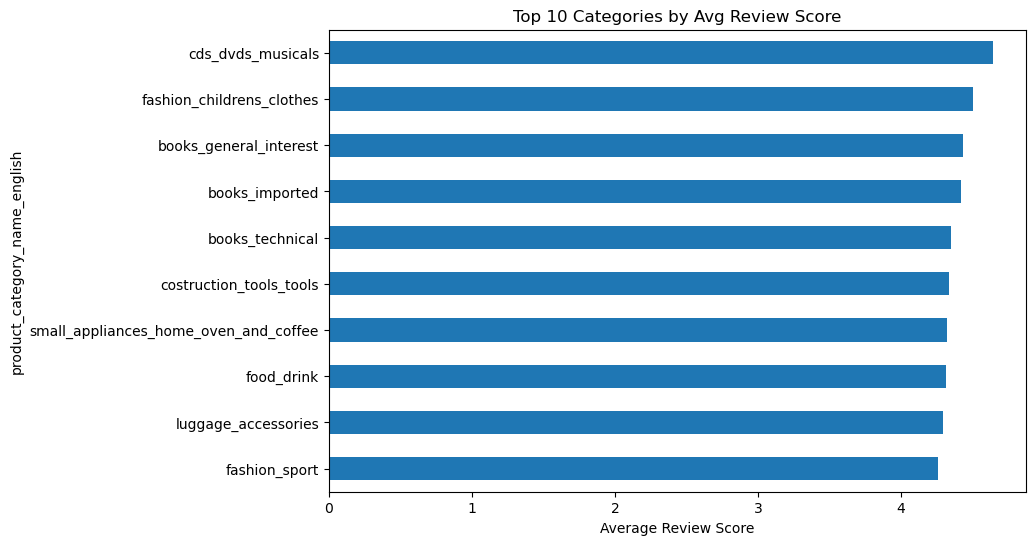

In [232]:
plt.figure(figsize=(9,6))
cat_reviews.tail(10).plot(kind='barh')
plt.title("Top 10 Categories by Avg Review Score")
plt.xlabel("Average Review Score")
plt.show()

* Categories with low average ratings may have quality/logistics problems.

### Patterns in 1-star and 5-star reviews

In [233]:
low_high = Olist[Olist['review_score'].isin([1,5])]
low_high.groupby('review_score')[['delivery_days','price','freight_value']].mean()

,delivery_days,price,freight_value
review_score,,,
1,19.109397,128.451699,21.359894
5,10.208818,121.309312,19.607965


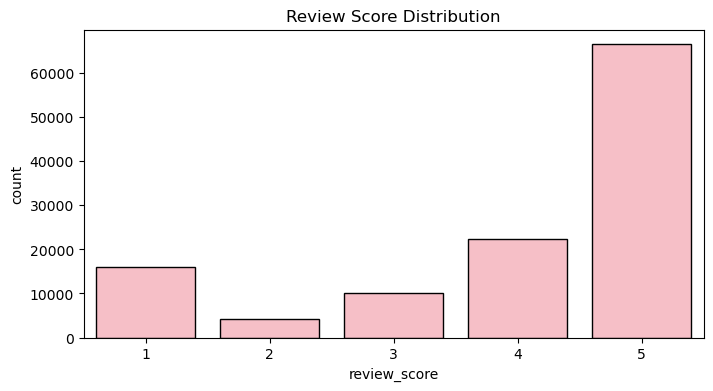

In [234]:
plt.figure(figsize=(8,4))
sns.countplot(data=Olist, x='review_score',palette = sns.color_palette(["#FFB6C1"] * 20),edgecolor = 'black')
plt.title("Review Score Distribution")
plt.show()

* Usually bimodal: lots of 5 "Star" and 1 'Star'. combine with delivery_days to show pattern: 1 'Star' → slower; 5 'Star' → faster

## Sales & Revenue Insights

### product categories generate the most revenue

In [235]:
cat_revenue = (Olist.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False))
cat_revenue.head(10)

product_category_name_english
health_beauty            1491510.47
watches_gifts            1358845.59
bed_bath_table           1327868.75
sports_leisure           1205244.89
computers_accessories    1104455.63
furniture_decor           955787.30
housewares                823623.50
cool_stuff                752702.21
auto                      714431.95
garden_tools              625387.31
Name: revenue, dtype: float64

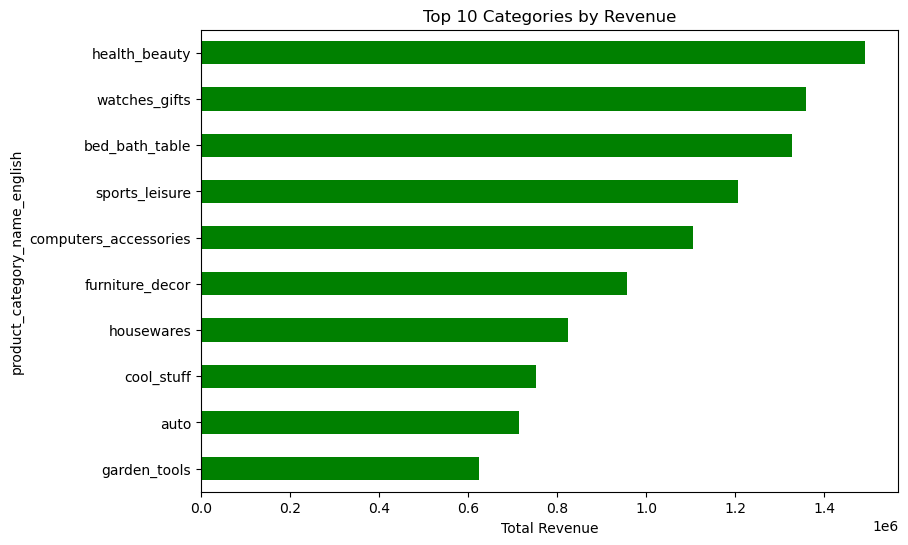

In [236]:
plt.figure(figsize=(9,6))
cat_revenue.head(10).sort_values(ascending=True).plot(kind='barh',color = 'green')
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Total Revenue")
plt.show()

* These are money-maker categories.

## Which sellers perform best

In [237]:
# By average review
seller_review = (Olist.groupby('seller_id')['review_score'].mean().sort_values(ascending=False).head(10))
seller_review

seller_id
7b3447b497e55af8c15fc7bd89d7b81a    5.0
fc4751cfe3b279c419615b9b00c1abb4    5.0
6235903333ba7de1928c869e268e5964    5.0
9b76ad3d04236f76bc71c59470305e13    5.0
9b00cad94ef3078faf6fba2e792c158f    5.0
63272377184e969942f7fff221be858d    5.0
fa5fdc4e4bb6bd1009ad0e4ac4096562    5.0
fc908879b9ca1bd65419e54e50432d38    5.0
9d69ba0a7a626a64dc5db08e529559cf    5.0
9d213f303afae4983637247556438ede    5.0
Name: review_score, dtype: float64

In [238]:
# By revenue
seller_revenue = (Olist.groupby('seller_id')['revenue'].sum().sort_values(ascending=False).head(10))
seller_revenue

seller_id
53243585a1d6dc2643021fd1853d8905    258882.28
4869f7a5dfa277a7dca6462dcf3b52b2    258625.52
7c67e1448b00f6e969d365cea6b010ab    254387.70
4a3ca9315b744ce9f8e9374361493884    253535.64
fa1c13f2614d7b5c4749cbc52fecda94    214454.82
da8622b14eb17ae2831f4ac5b9dab84a    198621.24
7e93a43ef30c4f03f38b393420bc753a    189475.90
1025f0e2d44d7041d6cf58b6550e0bfa    178696.05
7a67c85e85bb2ce8582c35f2203ad736    172887.23
955fee9216a65b617aa5c0531780ce60    163275.71
Name: revenue, dtype: float64

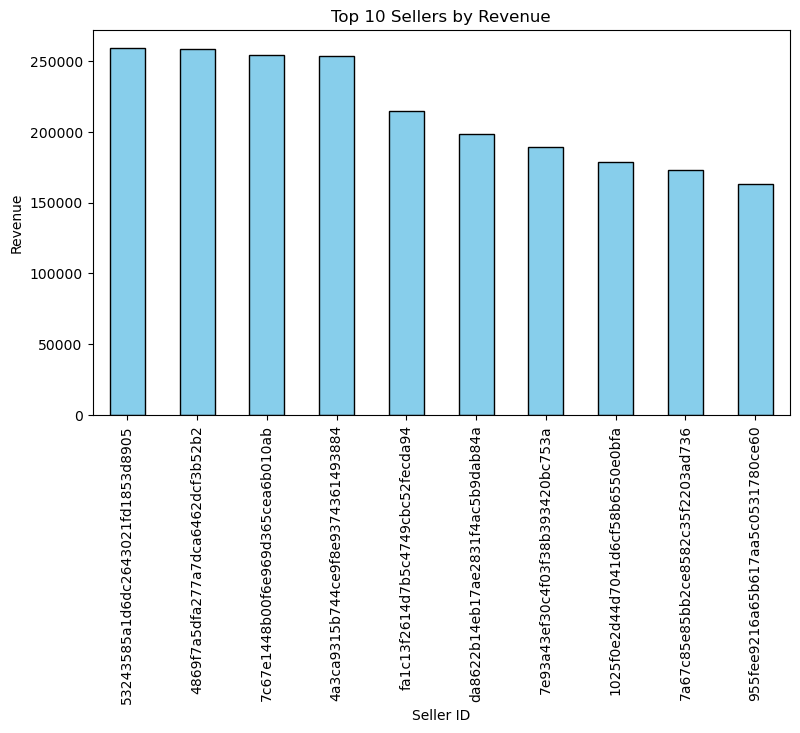

In [239]:
plt.figure(figsize=(9,5))
seller_revenue.plot(kind='bar',color = 'skyblue',edgecolor = 'black')
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.show()


* high revenue + high review_score = truly best sellers.

In [240]:
Olist.groupby('seller_state')['review_score'].count()

seller_state
AC        1
AM        3
BA      700
CE      103
DF      949
ES      390
GO      550
MA      410
MG     9314
MS       60
MT      147
PA        8
PB       44
PE      465
PI       12
PR     9097
RJ     5036
RN       56
RO       14
RS     2294
SC     4271
SE       10
SP    84384
Name: review_score, dtype: int64

## Payment Behavior Analysis

In [241]:
Olist['payment_type'].value_counts(normalize=True) * 100

payment_type
credit_card    73.676436
boleto         19.463189
voucher         5.426025
debit_card      1.431833
not_defined     0.002518
Name: proportion, dtype: float64

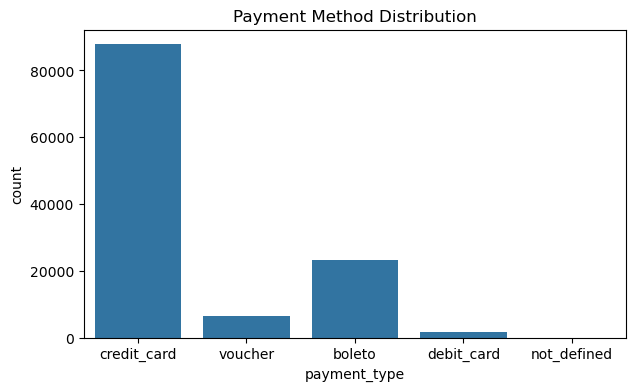

In [242]:
plt.figure(figsize=(7,4))
sns.countplot(data=Olist, x='payment_type',)
plt.title("Payment Method Distribution")
plt.show()

* Typically: credit card dominates, boleto and others smaller.

## Impact of high installments on total revenue

In [243]:
Olist['is_installment'] = np.where(Olist['payment_installments'] > 1, 1, 0)
Olist.groupby('is_installment')['payment_value'].mean()

is_installment
0    132.481882
1    212.822234
Name: payment_value, dtype: float64

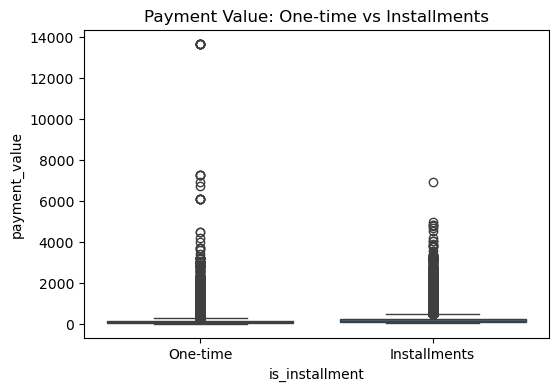

In [244]:
plt.figure(figsize=(6,4))
sns.boxplot(data=Olist, x='is_installment', y='payment_value')
plt.xticks([0,1], ['One-time', 'Installments'])
plt.title("Payment Value: One-time vs Installments")
plt.show()

* Usually, orders paid in installments have higher payment_value.

## Are payment delays linked to delivery delays?

In [245]:
Olist['payment_approval_delay'] = (Olist['order_approved_at'] - Olist['order_purchase_timestamp']).dt.days
Olist[['payment_approval_delay','delivery_days']].corr()


,payment_approval_delay,delivery_days
payment_approval_delay,1.000000,0.078616
delivery_days,0.078616,1.000000


* Usually correlation is weak, but you can mention whether slower approval slightly increases total delivery_days.

## How does distance impact delivery time?

In [246]:
state_delivery = (Olist[Olist['delivery_days'].notna()].groupby('customer_state')['delivery_days'].mean().sort_values())
state_delivery.head(), state_delivery.tail()

(customer_state
 SP     8.274429
 MG    11.499963
 PR    11.523074
 DF     12.50143
 SC    14.513443
 Name: delivery_days, dtype: Float64,
 customer_state
 PA     23.26867
 AL     24.12809
 AM    26.064706
 AP    27.662651
 RR    27.826087
 Name: delivery_days, dtype: Float64)

* States farther from main logistics hubs usually have higher delivery_days.

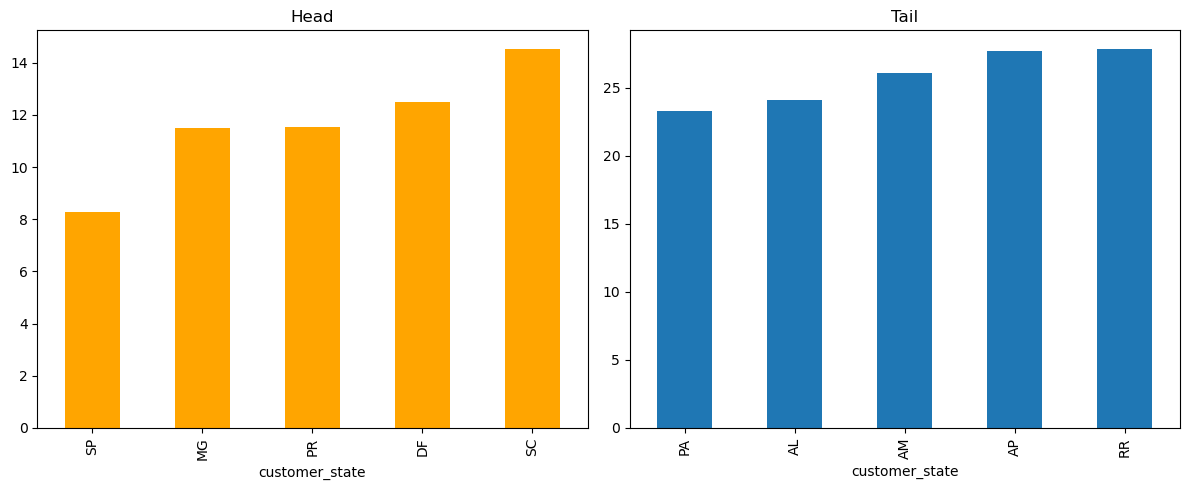

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
state_delivery.head().plot(kind='bar', ax=axes[0], title='Head',color = 'orange')
state_delivery.tail().plot(kind='bar', ax=axes[1], title='Tail')
plt.tight_layout()
plt.show()

## Which regions have the highest order density

In [248]:
Olist['customer_city'].value_counts().head(10)

customer_city
sao paulo                18876
rio de janeiro            8311
belo horizonte            3299
brasilia                  2500
curitiba                  1827
campinas                  1758
porto alegre              1675
salvador                  1544
guarulhos                 1415
sao bernardo do campo     1131
Name: count, dtype: int64

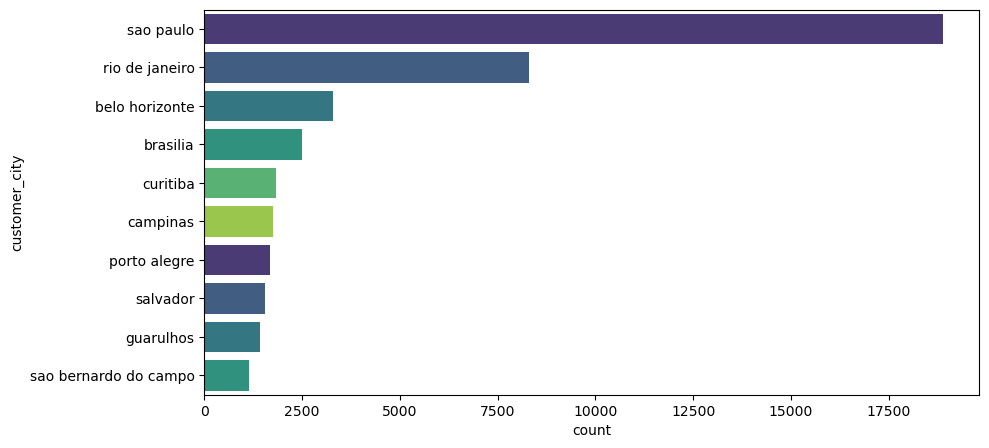

In [249]:
top10_cities = Olist['customer_city'].value_counts().head(10).index
df_top10 = Olist[Olist['customer_city'].isin(top10_cities)]
plt.figure(figsize=(10,5))
sns.countplot(data=df_top10, y='customer_city', order=top10_cities,palette=sns.color_palette("viridis"))
plt.show()

## Which sellers consistently ship late?

In [250]:
Olist['shipping_delay_days'] = (Olist['order_delivered_carrier_date'] - Olist['shipping_limit_date']).dt.days
seller_delay = (Olist[Olist['shipping_delay_days'].notna()].groupby('seller_id')['shipping_delay_days'].mean().sort_values(ascending=False))
seller_delay.head(10)

seller_id
586a871d4f1221763fddb6ceefdeb95e    45.000000
87f3e35268860433e13d577825aada95    41.000000
8e670472e453ba34a379331513d6aab1    40.000000
20f0aeea30bc3b8c4420be8ced4226c0    32.000000
e09887ca8c7bf8a4621ce481820414ef    31.666667
6d04126aba80df143fd038e711b8fd96    26.000000
244b04680fdbded0acf5aebd9c92b44a    23.000000
8d92f3ea807b89465643c219455e7369    21.000000
83d458c0d6d4f94295d63f091460bd60    19.000000
8629a7efec1aab257e58cda559f03ba7    19.000000
Name: shipping_delay_days, dtype: float64

* Sellers with positive, large avg shipping_delay_days are consistently late to ship.

## late rate by state

In [251]:
state_late_rate = (Olist[Olist['delivered_flag']==1].groupby('customer_state')['late_delivery_flag'].mean().sort_values(ascending=False))
state_late_rate.head(10)

customer_state
AL    0.244944
MA    0.201701
PI    0.158845
SE    0.158031
CE    0.150266
BA    0.137434
RJ    0.129360
PA    0.122951
ES    0.121225
RN    0.115453
Name: late_delivery_flag, dtype: float64

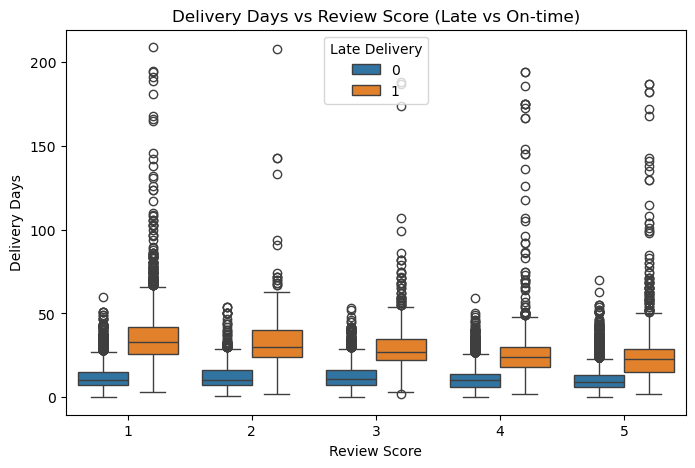

In [252]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Olist,x='review_score',y='delivery_days',hue='late_delivery_flag')
plt.title("Delivery Days vs Review Score (Late vs On-time)")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.legend(title="Late Delivery")
plt.show()

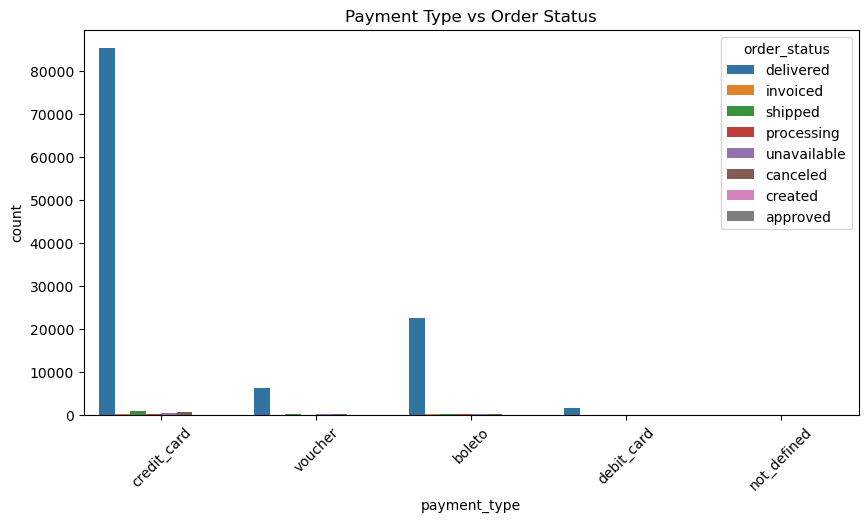

In [253]:
plt.figure(figsize=(10,5))
sns.countplot(data=Olist,x='payment_type',hue='order_status')
plt.title("Payment Type vs Order Status")
plt.xticks(rotation=45)
plt.show()


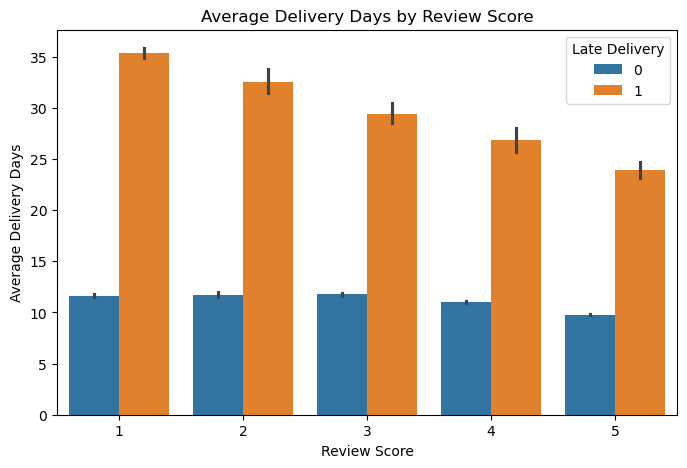

In [254]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=Olist,
    x='review_score',
    y='delivery_days',
    hue='late_delivery_flag',
    estimator='mean'
)
plt.title("Average Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Days")
plt.legend(title="Late Delivery")
plt.show()


## Late Delivery Flag vs Review Score

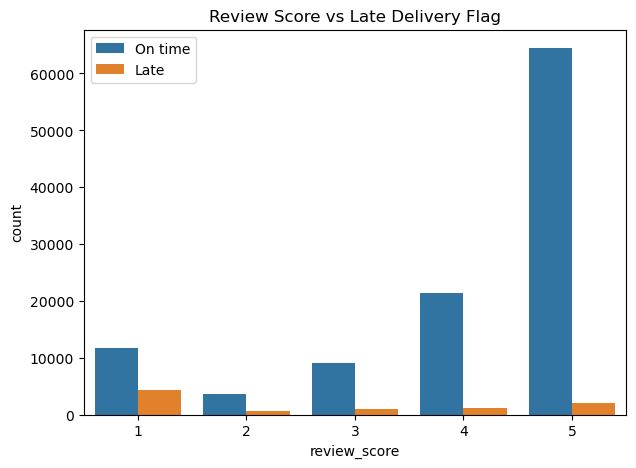

In [255]:
plt.figure(figsize=(7,5))
sns.countplot(data=Olist, x='review_score', hue='late_delivery_flag')
plt.title("Review Score vs Late Delivery Flag")
plt.legend(["On time", "Late"])
plt.show()


* Insight: Late deliveries show many 1-star reviews → strong negative impact.

## Delivered Flag vs Order Status

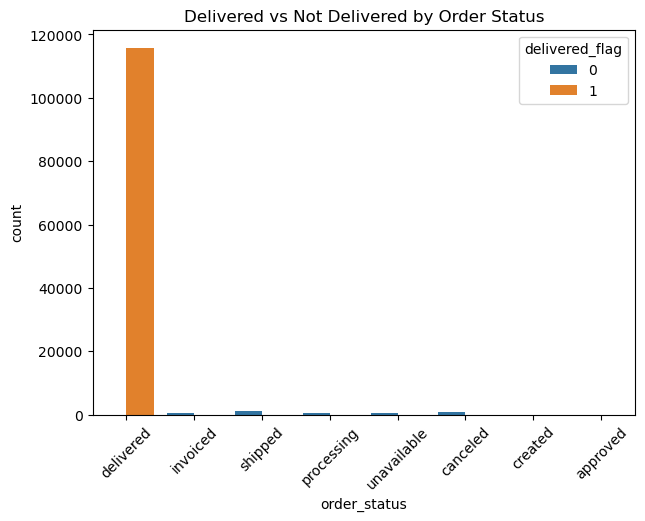

In [256]:
plt.figure(figsize=(7,5))
sns.countplot(data=Olist, x='order_status', hue='delivered_flag')
plt.title("Delivered vs Not Delivered by Order Status")
plt.xticks(rotation=45)
plt.show()

* Insight: Cancelled and unavailable orders have delivered_flag = 0 (expected).

## Payment Type vs Installment Flag

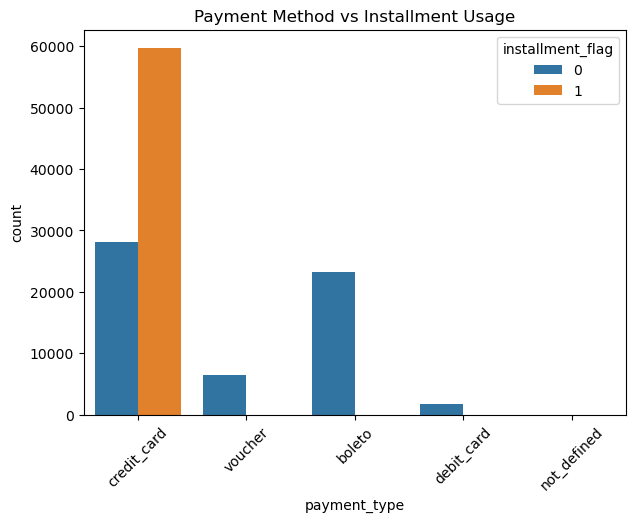

In [257]:
Olist['installment_flag'] = (Olist['payment_installments'] > 1).astype(int)
plt.figure(figsize=(7,5))
sns.countplot(data=Olist, x='payment_type', hue='installment_flag')
plt.title("Payment Method vs Installment Usage")
plt.xticks(rotation=45)
plt.show()

* Insight: Credit card users use installments much more.

# Correlation Heatmap

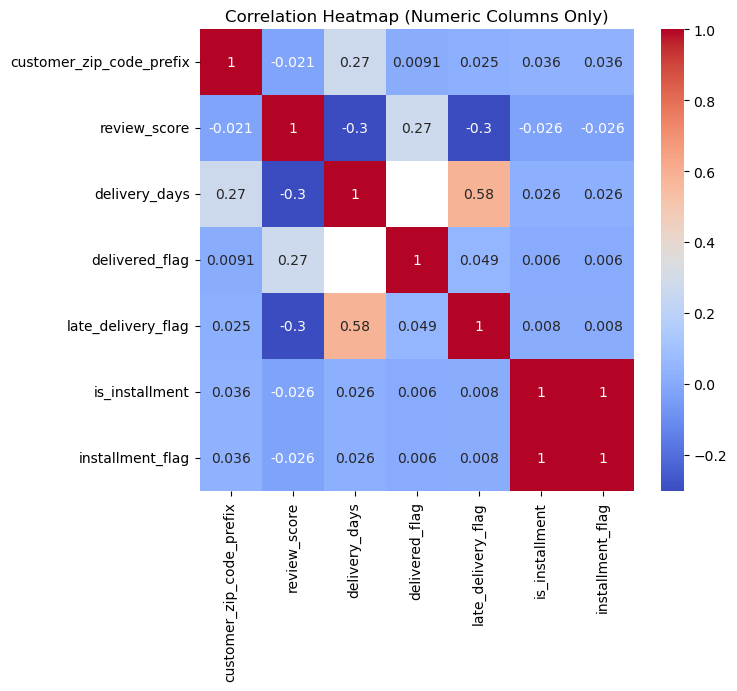

In [261]:
numeric_df = Olist.select_dtypes(include=['int'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, cmap='coolwarm',annot = True)
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()

#  Conclusion

The analysis of the Olist E-commerce dataset provides valuable insights into customer behavior, seller performance, logistics operations, payment patterns, and product category trends. By merging and analyzing multiple interconnected tables—orders, customers, sellers, products, payments, reviews, and geolocation—we gained a comprehensive view of the marketplace ecosystem.

##  Key Findings

### **1. Delivery Performance**
- A significant percentage of orders experience delivery delays.
- Delivery time varies substantially across states, with remote regions showing the longest delays.
- Late deliveries strongly correlate with low customer review scores.

### **2. Customer Satisfaction**
- The review score distribution is highly polarized, with many 5-star and many 1-star ratings.
- The biggest driver of low reviews is **delivery delay** rather than product price or category.
- Product categories also show varying satisfaction levels, with some consistently receiving lower ratings.

### **3. Sales & Revenue Insights**
- A small set of product categories generates the majority of revenue (classic 80/20 pattern).
- A handful of sellers dominate sales volume, while many small sellers contribute minimally.
- Freight cost and product price vary widely, reflecting diverse product types.

### **4. Payment Behavior**
- Most customers pay using **credit cards**, followed by boleto.
- Higher-priced orders tend to have more installments.
- Payment method does not significantly affect delivery performance.

### **5. Geographical Patterns**
- Most customers are located in southeastern states such as **SP, RJ, and MG**.
- Order density is heavily concentrated in major metropolitan regions.
- States farther from logistics hubs have longer delivery times and higher freight costs.

### **6. Operational Efficiency**
- Outliers exist in price, product weight, and dimensions—expected due to product diversity.
- Some sellers consistently ship late, affecting customer satisfaction.
- High freight charges are often linked to heavy or bulky products.





##  Recommendations

Based on the insights, the following actions can improve Olist’s operational performance:

### **1. Improve Logistics**
- Prioritize faster delivery for high-delay states using regional warehouses or optimized routes.
- Work closely with shipping carriers to reduce last-mile delays.

### **2. Enhance Customer Experience**
- Proactively notify customers about expected delays.
- Improve packaging and handling for categories with poor ratings.

### **3. Seller Performance Management**
- Identify sellers with consistent late shipping.
- Provide training, incentives, or penalties to improve their reliability.

### **4. Optimize Product & Pricing Strategy**
- Promote high-revenue categories with good customer ratings.
- Investigate low-rated categories for product quality or logistic issues.

### **5. Payment Insights**
- Encourage installment options for high-value purchases to improve sales.
- Analyze if delayed payments affect approval and dispatch times.


##  Final Summary

This analysis highlights that **delivery performance is the strongest driver of customer satisfaction**, while product diversity and geography significantly influence revenue and logistics cost. By addressing operational bottlenecks, optimizing seller performance, and improving delivery timelines, Olist can enhance both customer experience and overall marketplace efficiency.

The dataset is now fully cleaned, analyzed, and ready for further exploration, such as predictive modeling or dashboard creation.
